## Imports and Dependencies

In [1]:
# ============================================================
# SECTION 1 — IMPORTS AND DEPENDENCIES
# ============================================================

# ── Standard library ──────────────────────────────────────
import re
import warnings
warnings.filterwarnings('ignore')

# ── Data handling ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Text processing (for Dataset 1 — email body/subject) ──
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Preprocessing ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ── Train-test split ──────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Models ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── Evaluation metrics ────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ── Model saving ──────────────────────────────────────────
import joblib

# ── Display settings ──────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print("All imports successful")
print(f"Pandas version   : {pd.__version__}")
print(f"NumPy version    : {np.__version__}")
print(f"Joblib version   : {joblib.__version__}")

All imports successful
Pandas version   : 2.3.3
NumPy version    : 2.0.2
Joblib version   : 1.5.3


In [2]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Sat Mar 28 23:18:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import xgboost as xgb

## Load Dataset

In [4]:
# ============================================================
# SECTION 2 — LOAD DATASET
# ============================================================

import os

# ── Confirm exact Kaggle paths ─────────────────────────────
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/SpamAssasin.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/Nazario.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/Nigerian_Fraud.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/CEAS_08.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/Enron.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/Ling.csv
/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/phishing_email.csv
/kaggle/input/datasets/shashwatwork/phishing-dataset-for-machine-learning/Phishing_Legitimate_full.csv


In [5]:
# ============================================================
# SECTION 2 — LOAD DATASET
# ============================================================

import os
import numpy as np
import pandas as pd

# ── Dataset 1: individual email files ─────────────────────
BASE = '/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset'

ceas           = pd.read_csv(f'{BASE}/CEAS_08.csv')
enron          = pd.read_csv(f'{BASE}/Enron.csv')
ling           = pd.read_csv(f'{BASE}/Ling.csv')
nazario        = pd.read_csv(f'{BASE}/Nazario.csv')
nigerian       = pd.read_csv(f'{BASE}/Nigerian_Fraud.csv')
spam           = pd.read_csv(f'{BASE}/SpamAssasin.csv')
phishing_email = pd.read_csv(f'{BASE}/phishing_email.csv')

# ── Dataset 2: URL feature-based ──────────────────────────
url_df = pd.read_csv('/kaggle/input/datasets/shashwatwork/phishing-dataset-for-machine-learning/Phishing_Legitimate_full.csv')

# ──────────────────────────────────────────────────────────
# phishing_email.csv has only text_combined + label
# Split text_combined into subject + body
# ──────────────────────────────────────────────────────────
phishing_email['subject'] = phishing_email['text_combined'].apply(
    lambda x: str(x).split('.')[0] if pd.notnull(x) else ''
)
phishing_email['body'] = phishing_email['text_combined'].apply(
    lambda x: '.'.join(str(x).split('.')[1:]) if pd.notnull(x) else ''
)
phishing_email = phishing_email.drop(columns=['text_combined'])

# ──────────────────────────────────────────────────────────
# Standardize all files to common columns before merging
# Files missing columns get NaN filled automatically
# ──────────────────────────────────────────────────────────

COMMON_COLS = ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

def standardize(df, source_name):
    for col in COMMON_COLS:
        if col not in df.columns:
            df[col] = np.nan
    df = df[COMMON_COLS].copy()
    df['source'] = source_name
    return df

ceas           = standardize(ceas,           'CEAS_08')
enron          = standardize(enron,          'Enron')
ling           = standardize(ling,           'Ling')
nazario        = standardize(nazario,        'Nazario')
nigerian       = standardize(nigerian,       'Nigerian_Fraud')
spam           = standardize(spam,           'SpamAssasin')
phishing_email = standardize(phishing_email, 'phishing_email')

# ── Merge all 7 into one email dataframe ──────────────────
email_df = pd.concat(
    [ceas, enron, ling, nazario, nigerian, spam, phishing_email],
    ignore_index=True
)

# ── Rename URL dataset label column to match email_df ─────
url_df = url_df.rename(columns={'CLASS_LABEL': 'label'})
url_df = url_df.drop(columns=['id'])

# ──────────────────────────────────────────────────────────
# Sanity checks
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("INDIVIDUAL FILE SIZES")
print("=" * 55)
print(f"CEAS_08         : {ceas.shape[0]:>7,} rows")
print(f"Enron           : {enron.shape[0]:>7,} rows")
print(f"Ling            : {ling.shape[0]:>7,} rows")
print(f"Nazario         : {nazario.shape[0]:>7,} rows")
print(f"Nigerian Fraud  : {nigerian.shape[0]:>7,} rows")
print(f"SpamAssasin     : {spam.shape[0]:>7,} rows")
print(f"Phishing Email  : {phishing_email.shape[0]:>7,} rows")

print("\n")
print("=" * 55)
print("DATASET 1 — Email dataset (merged)")
print("=" * 55)
print(f"Shape           : {email_df.shape}")
print(f"Columns         : {list(email_df.columns)}")
print(f"\nLabel distribution:")
print(email_df['label'].value_counts())
print(f"\nLabel % split:")
print(email_df['label'].value_counts(normalize=True).mul(100).round(2))
print(f"\nNull values per column:")
print(email_df.isnull().sum())
print(f"\nRows per source:")
print(email_df['source'].value_counts())

print("\n")
print("=" * 55)
print("DATASET 2 — URL feature dataset")
print("=" * 55)
print(f"Shape           : {url_df.shape}")
print(f"\nLabel distribution:")
print(url_df['label'].value_counts())
print(f"\nNull values: {url_df.isnull().sum().sum()}")

INDIVIDUAL FILE SIZES
CEAS_08         :  39,154 rows
Enron           :  29,767 rows
Ling            :   2,859 rows
Nazario         :   1,565 rows
Nigerian Fraud  :   3,332 rows
SpamAssasin     :   5,809 rows
Phishing Email  :  82,486 rows


DATASET 1 — Email dataset (merged)
Shape           : (164972, 8)
Columns         : ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label', 'source']

Label distribution:
label
1    85782
0    79190
Name: count, dtype: int64

Label % split:
label
1    52.0
0    48.0
Name: proportion, dtype: float64

Null values per column:
sender      115443
receiver    117204
date        115595
subject        347
body             1
urls        115112
label            0
source           0
dtype: int64

Rows per source:
source
phishing_email    82486
CEAS_08           39154
Enron             29767
SpamAssasin        5809
Nigerian_Fraud     3332
Ling               2859
Nazario            1565
Name: count, dtype: int64


DATASET 2 — URL feature dataset
Shape 

## EDA

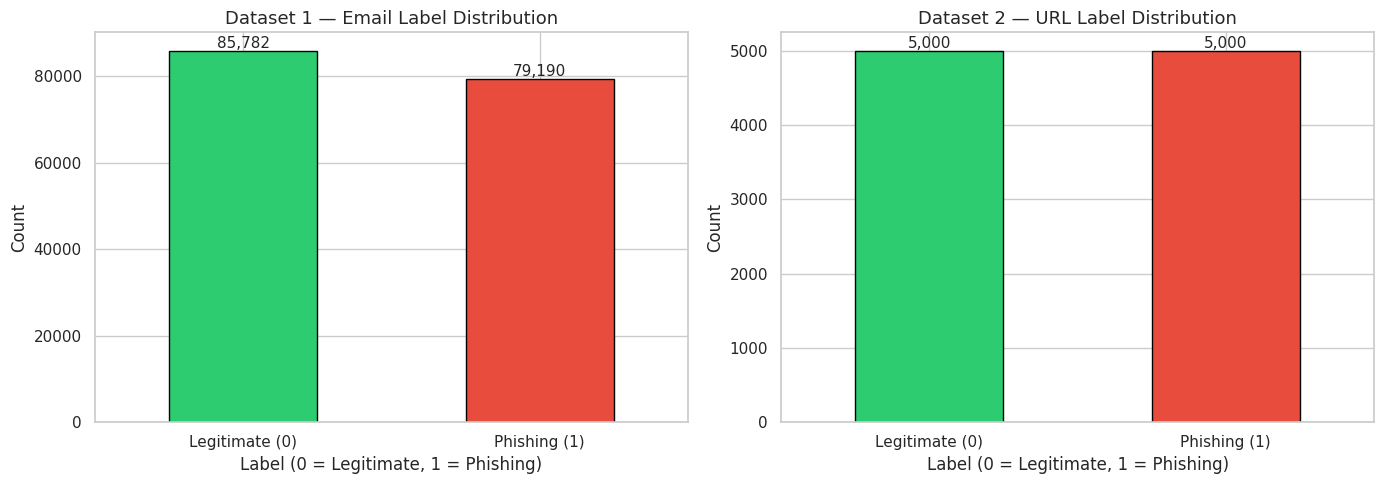

3.1 — Label distribution plotted


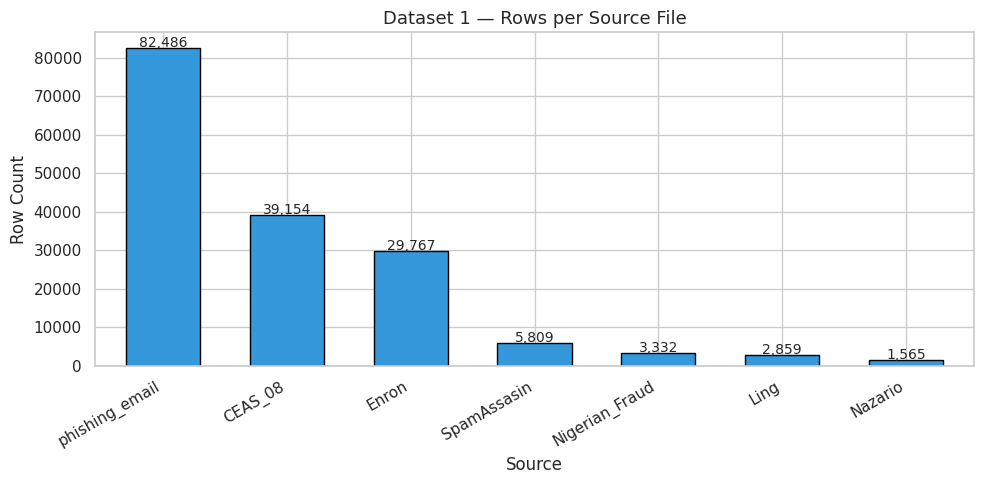

3.2 — Source distribution plotted


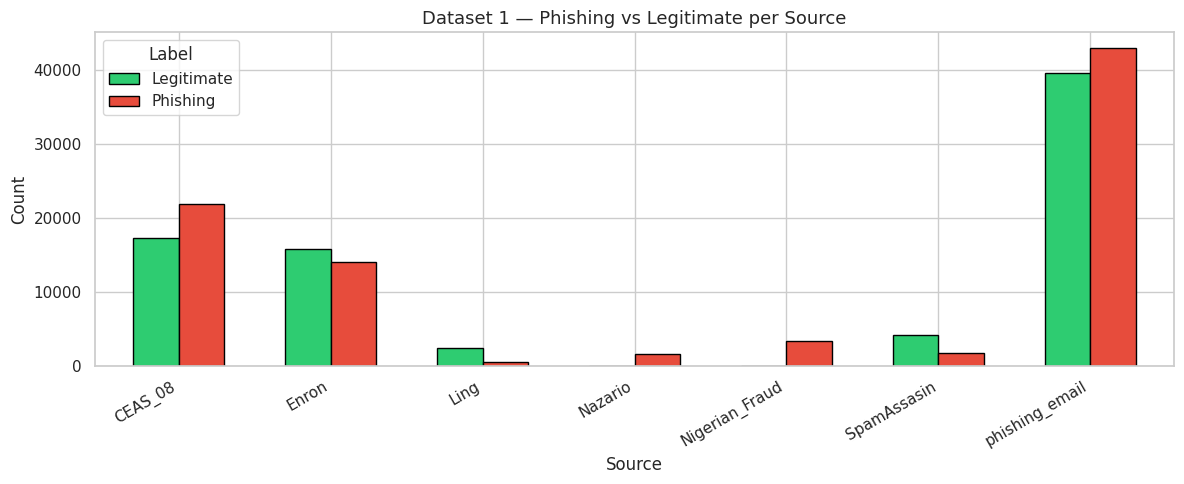

3.3 — Per-source label breakdown plotted


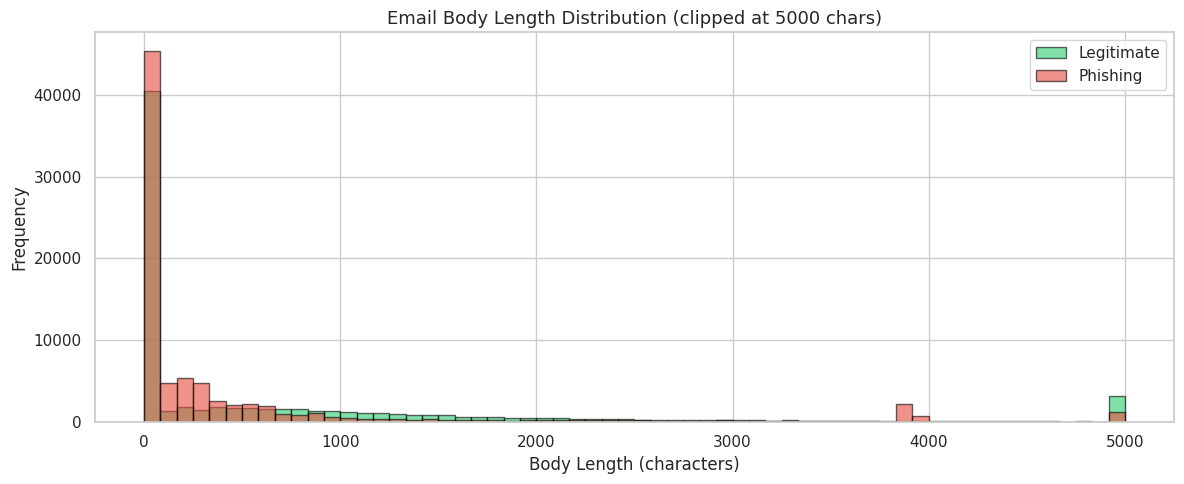

3.4 — Body length distribution plotted


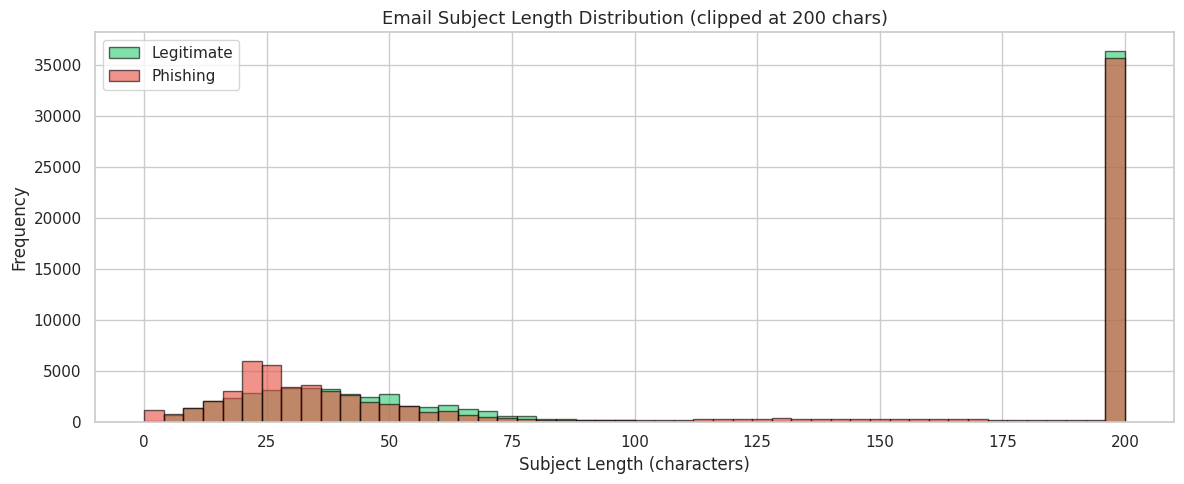

3.5 — Subject length distribution plotted


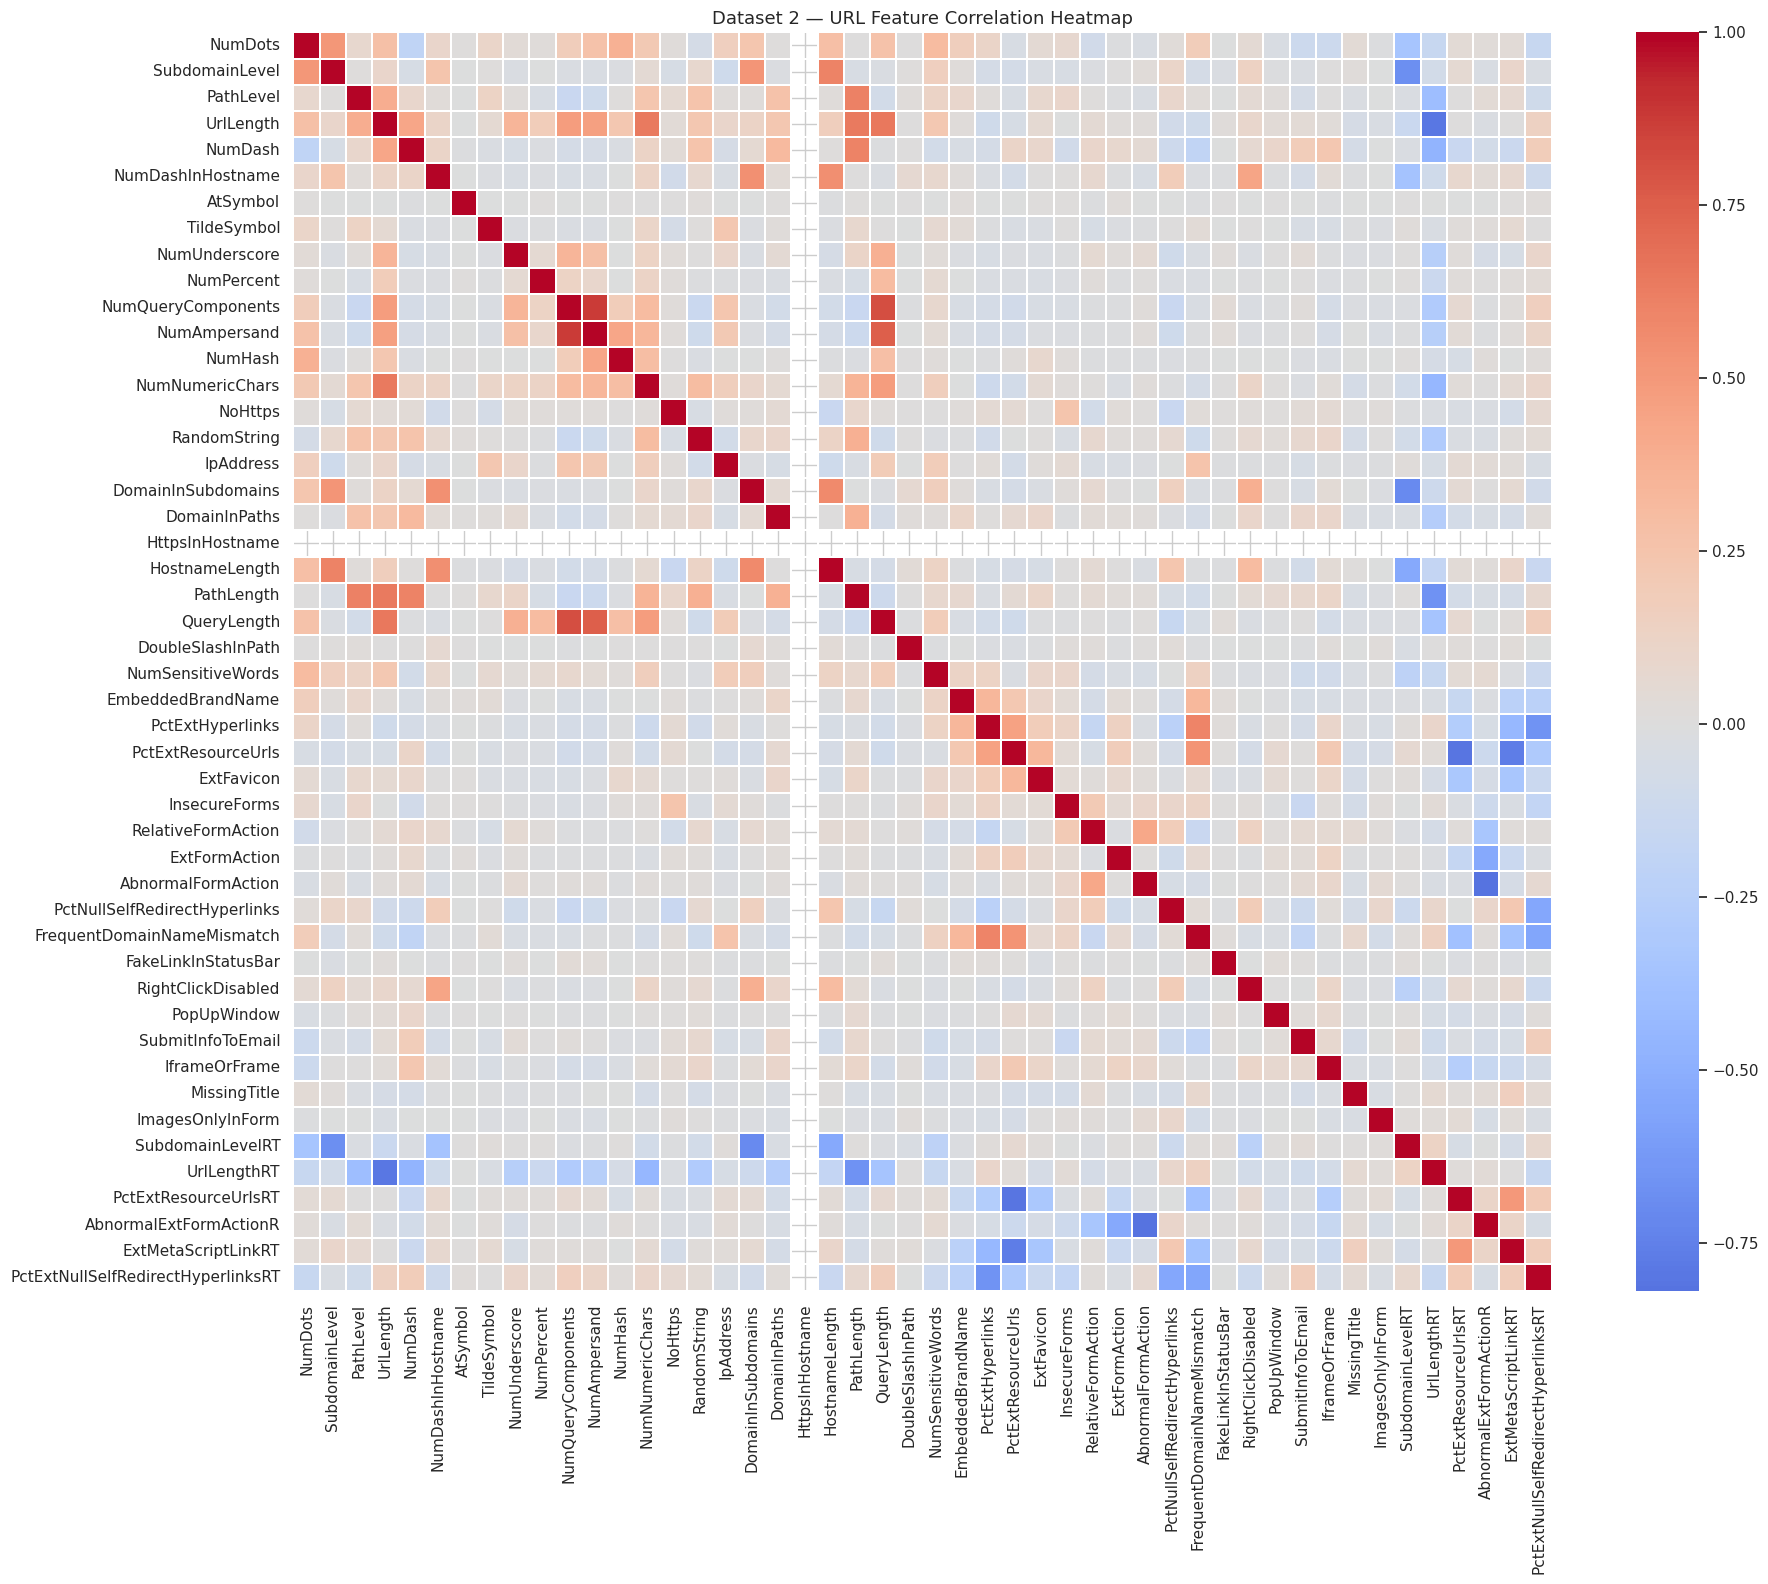

3.6 — URL feature correlation heatmap plotted


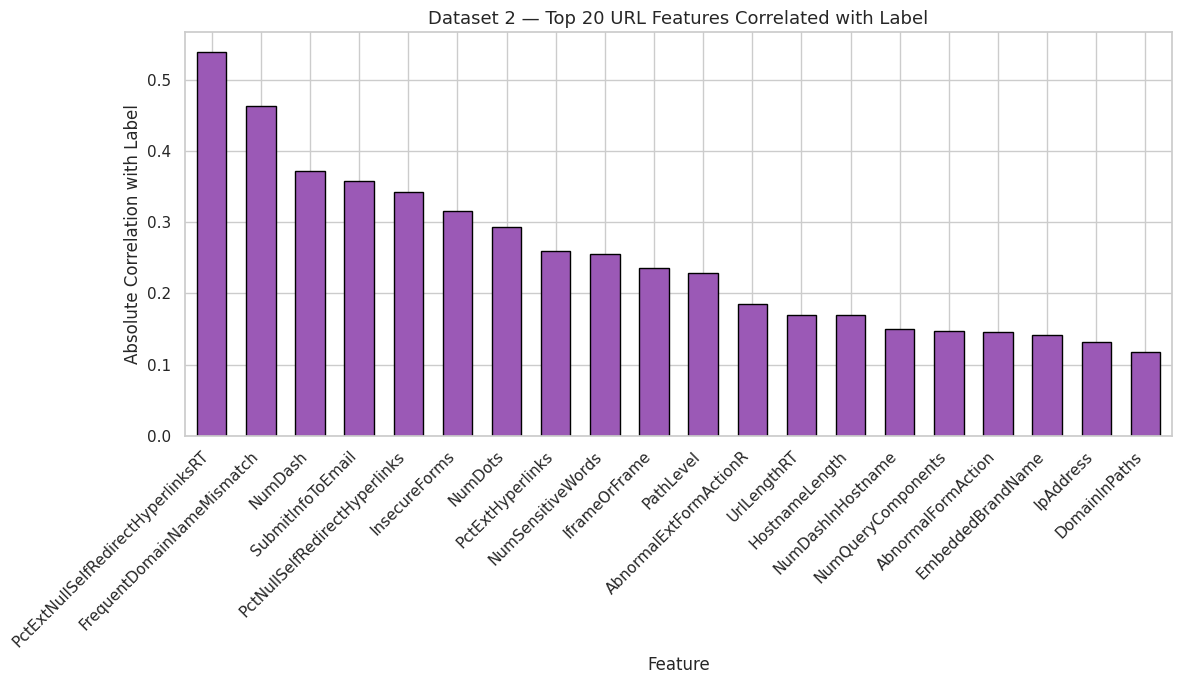

3.7 — Top URL feature correlations plotted


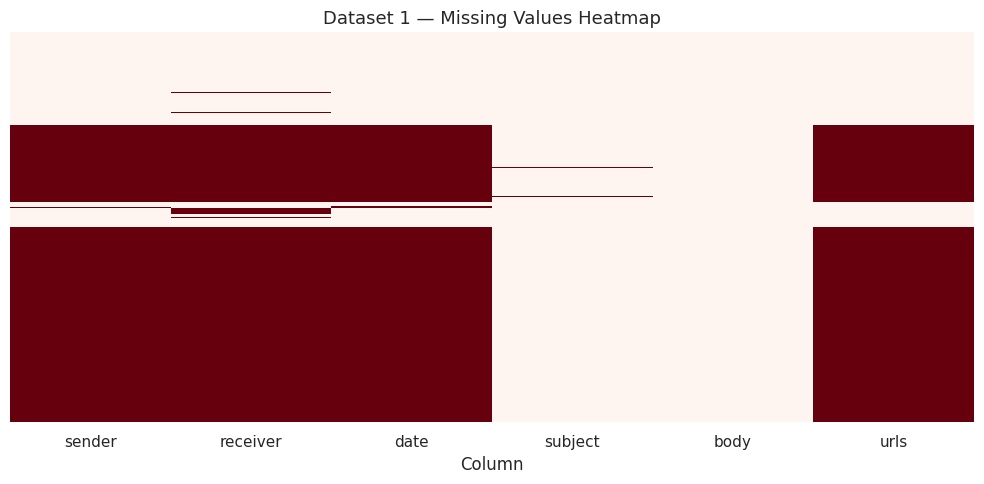

3.8 — Missing values heatmap plotted


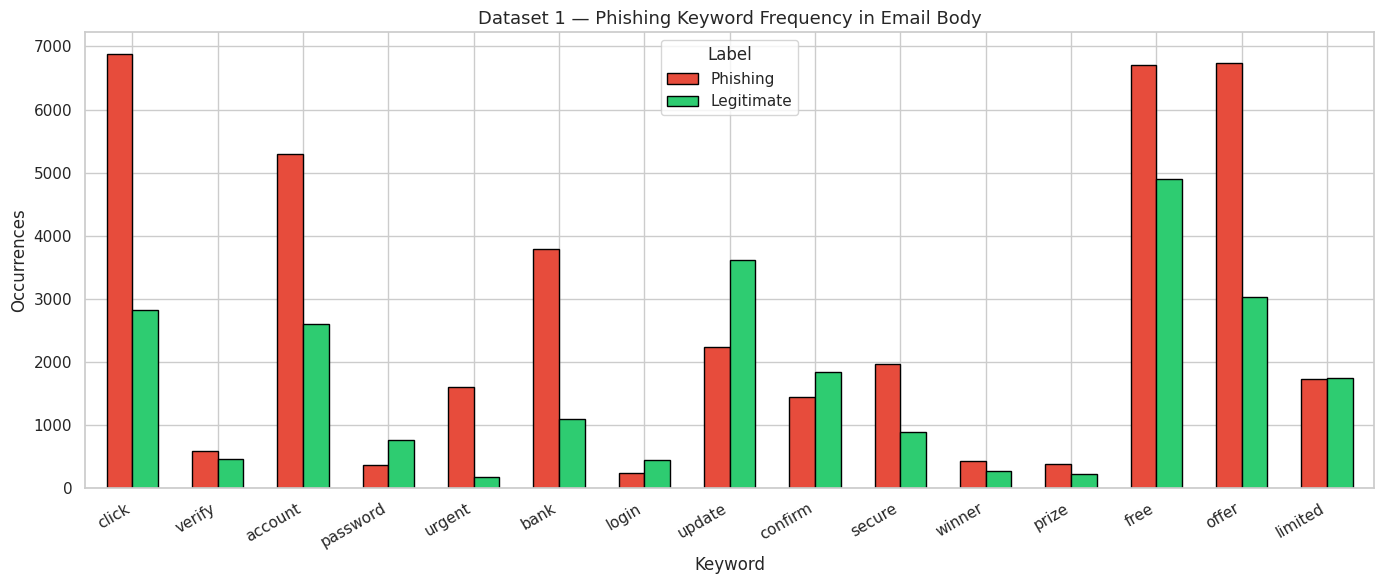

3.9 — Keyword frequency plotted


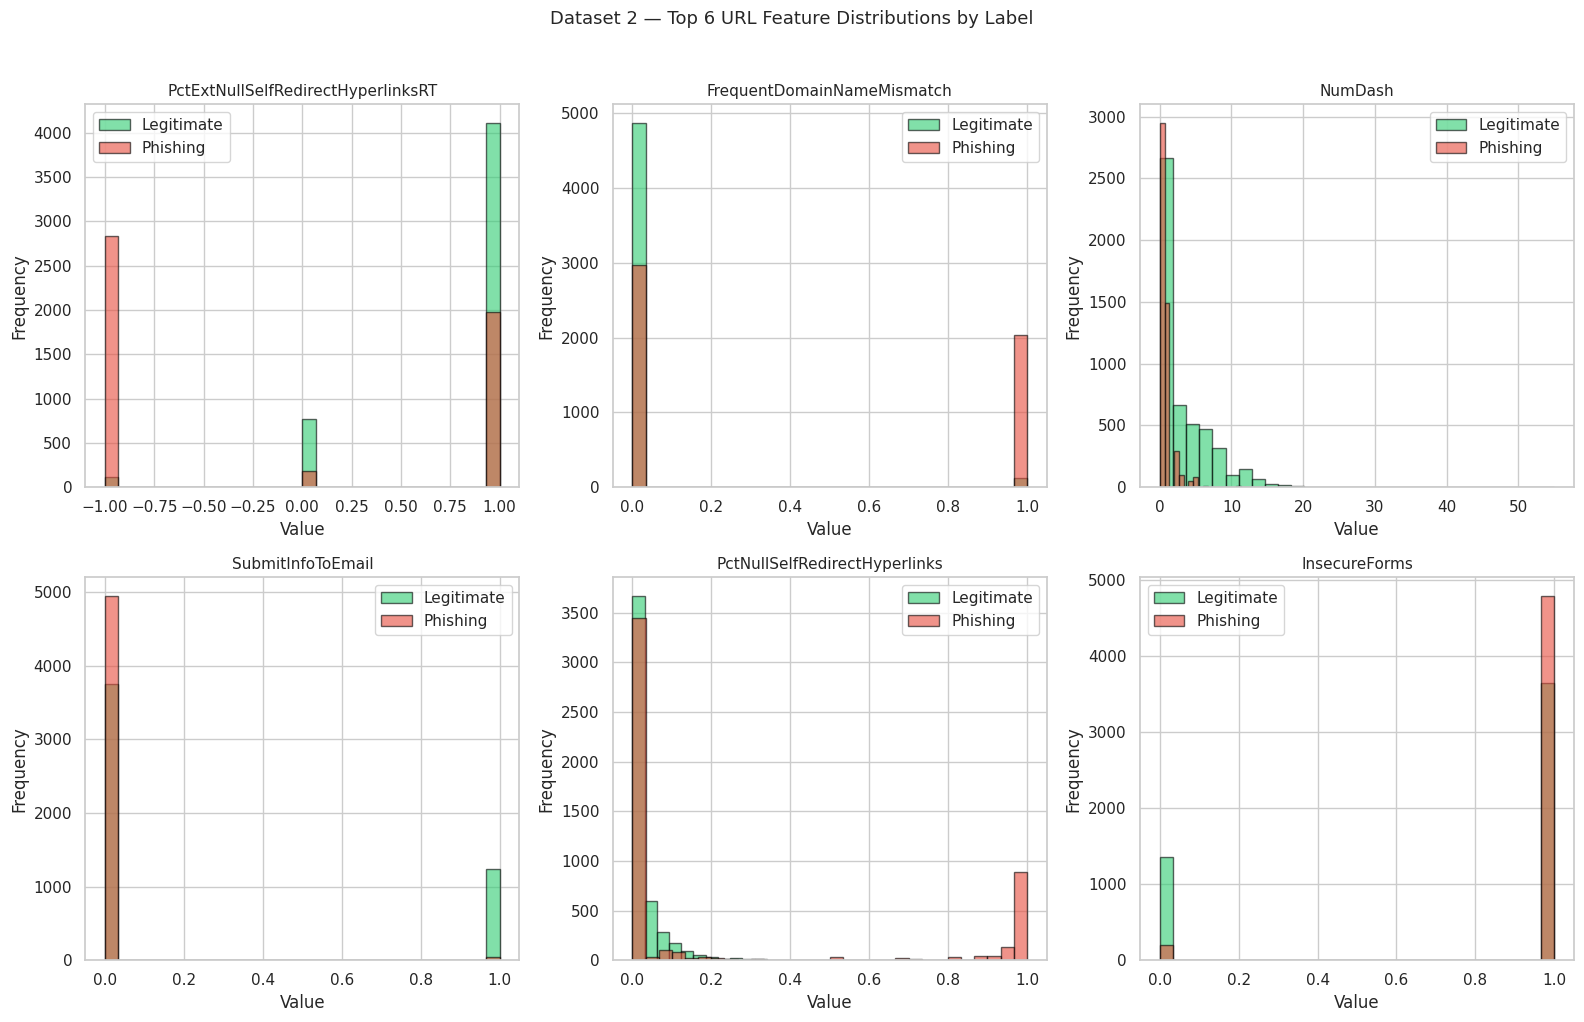

3.10 — URL feature distributions plotted


EDA SUMMARY
Total email samples       : 164,972
Phishing emails           : 85,782
Legitimate emails         : 79,190
Avg body length           : 880 chars
Avg subject length        : 662 chars
Phishing avg body length  : 696 chars
Legitimate avg body length: 1080 chars

Missing values in email_df:
sender            115443
receiver          117204
date              115595
subject              347
body                   1
urls              115112
label                  0
source                 0
body_length            0
subject_length         0
dtype: int64

Top 5 URL features by correlation with label:
PctExtNullSelfRedirectHyperlinksRT    0.540545
FrequentDomainNameMismatch            0.463956
NumDash                               0.372235
SubmitInfoToEmail                     0.357635
PctNullSelfRedirectHyperlinks         0.342806

Most frequent phishing keyword : click
Most frequent legit keyword    : free

EDA complete — 10 sections done


In [6]:
# ============================================================
# SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ── 3.1 Label distribution — Dataset 1 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

email_df['label'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Dataset 1 — Email Label Distribution', fontsize=13)
axes[0].set_xlabel('Label (0 = Legitimate, 1 = Phishing)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# ── 3.2 Label distribution — Dataset 2 ────────────────────
url_df['label'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
axes[1].set_title('Dataset 2 — URL Label Distribution', fontsize=13)
axes[1].set_xlabel('Label (0 = Legitimate, 1 = Phishing)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.1 — Label distribution plotted")

# ── 3.2 Rows per source ───────────────────────────────────
plt.figure(figsize=(10, 5))
source_counts = email_df['source'].value_counts()
source_counts.plot(
    kind='bar',
    color='#3498db',
    edgecolor='black',
    width=0.6
)
plt.title('Dataset 1 — Rows per Source File', fontsize=13)
plt.xlabel('Source')
plt.ylabel('Row Count')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(source_counts):
    plt.text(i, v + 300, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('rows_per_source.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.2 — Source distribution plotted")

# ── 3.3 Phishing vs Legitimate per source ─────────────────
source_label = email_df.groupby(['source', 'label']).size().unstack(fill_value=0)
source_label.columns = ['Legitimate', 'Phishing']
source_label.plot(
    kind='bar',
    figsize=(12, 5),
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.6
)
plt.title('Dataset 1 — Phishing vs Legitimate per Source', fontsize=13)
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.savefig('phishing_vs_legit_per_source.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.3 — Per-source label breakdown plotted")

# ── 3.4 Email body length distribution ────────────────────
email_df['body_length'] = email_df['body'].fillna('').apply(len)

plt.figure(figsize=(12, 5))
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Phishing')]:
    subset = email_df[email_df['label'] == label]['body_length']
    subset.clip(upper=5000).plot(
        kind='hist',
        bins=60,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor='black'
    )
plt.title('Email Body Length Distribution (clipped at 5000 chars)', fontsize=13)
plt.xlabel('Body Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('body_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.4 — Body length distribution plotted")

# ── 3.5 Subject length distribution ───────────────────────
email_df['subject_length'] = email_df['subject'].fillna('').apply(len)

plt.figure(figsize=(12, 5))
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Phishing')]:
    subset = email_df[email_df['label'] == label]['subject_length']
    subset.clip(upper=200).plot(
        kind='hist',
        bins=50,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor='black'
    )
plt.title('Email Subject Length Distribution (clipped at 200 chars)', fontsize=13)
plt.xlabel('Subject Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('subject_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.5 — Subject length distribution plotted")

# ── 3.6 URL feature correlations — Dataset 2 ──────────────
plt.figure(figsize=(20, 16))
corr = url_df.drop(columns=['label']).corr()
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,
    square=True
)
plt.title('Dataset 2 — URL Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('url_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.6 — URL feature correlation heatmap plotted")

# ── 3.7 Top URL features correlated with label ────────────
label_corr = url_df.corr()['label'].drop('label').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
label_corr.head(20).plot(
    kind='bar',
    color='#9b59b6',
    edgecolor='black',
    width=0.6
)
plt.title('Dataset 2 — Top 20 URL Features Correlated with Label', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation with Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_url_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.7 — Top URL feature correlations plotted")

# ── 3.8 Missing values heatmap — Dataset 1 ────────────────
plt.figure(figsize=(10, 5))
missing = email_df[['sender', 'receiver', 'date', 'subject', 'body', 'urls']].isnull()
sns.heatmap(
    missing,
    cbar=False,
    cmap='Reds',
    yticklabels=False
)
plt.title('Dataset 1 — Missing Values Heatmap', fontsize=13)
plt.xlabel('Column')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.8 — Missing values heatmap plotted")

# ── 3.9 Phishing keyword frequency in email body ──────────
PHISHING_KEYWORDS = [
    'click', 'verify', 'account', 'password', 'urgent',
    'bank', 'login', 'update', 'confirm', 'secure',
    'winner', 'prize', 'free', 'offer', 'limited'
]

keyword_phishing    = {}
keyword_legitimate  = {}

phishing_bodies    = email_df[email_df['label'] == 1]['body'].fillna('').str.lower()
legitimate_bodies  = email_df[email_df['label'] == 0]['body'].fillna('').str.lower()

for kw in PHISHING_KEYWORDS:
    keyword_phishing[kw]   = phishing_bodies.str.contains(kw).sum()
    keyword_legitimate[kw] = legitimate_bodies.str.contains(kw).sum()

kw_df = pd.DataFrame({
    'Phishing'   : keyword_phishing,
    'Legitimate' : keyword_legitimate
})

kw_df.plot(
    kind='bar',
    figsize=(14, 6),
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.6
)
plt.title('Dataset 1 — Phishing Keyword Frequency in Email Body', fontsize=13)
plt.xlabel('Keyword')
plt.ylabel('Occurrences')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.savefig('keyword_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.9 — Keyword frequency plotted")

# ── 3.10 URL feature distributions — top 6 features ───────
top_features = label_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Phishing')]:
        subset = url_df[url_df['label'] == label][feature]
        axes[i].hist(
            subset,
            bins=30,
            alpha=0.6,
            color=color,
            label=name,
            edgecolor='black'
        )
    axes[i].set_title(f'{feature}', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Dataset 2 — Top 6 URL Feature Distributions by Label', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('url_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("3.10 — URL feature distributions plotted")

# ── 3.11 Summary stats ────────────────────────────────────
print("\n")
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"Total email samples       : {email_df.shape[0]:,}")
print(f"Phishing emails           : {(email_df['label']==1).sum():,}")
print(f"Legitimate emails         : {(email_df['label']==0).sum():,}")
print(f"Avg body length           : {email_df['body_length'].mean():.0f} chars")
print(f"Avg subject length        : {email_df['subject_length'].mean():.0f} chars")
print(f"Phishing avg body length  : {email_df[email_df['label']==1]['body_length'].mean():.0f} chars")
print(f"Legitimate avg body length: {email_df[email_df['label']==0]['body_length'].mean():.0f} chars")
print(f"\nMissing values in email_df:")
print(email_df.isnull().sum())
print(f"\nTop 5 URL features by correlation with label:")
print(label_corr.head(5).to_string())
print(f"\nMost frequent phishing keyword : {max(keyword_phishing, key=keyword_phishing.get)}")
print(f"Most frequent legit keyword    : {max(keyword_legitimate, key=keyword_legitimate.get)}")
print(f"\nEDA complete — 10 sections done")

## Data Preprocessing and Cleaning

In [7]:
# ============================================================
# SECTION 4 — DATA PREPROCESSING AND CLEANING
# ============================================================

import re
from sklearn.preprocessing import StandardScaler

# ──────────────────────────────────────────────────────────
# 4.1 DATASET 1 — EMAIL PREPROCESSING
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("4.1 — Email Dataset Preprocessing")
print("=" * 55)

# ── Step 1: Drop columns with excessive nulls ──────────────
# sender, receiver, date, urls have 115k+ nulls
# not useful for text-based ML — drop them
DROP_COLS = ['sender', 'receiver', 'date', 'urls', 'source']
email_clean = email_df.drop(columns=DROP_COLS)
print(f"Dropped columns  : {DROP_COLS}")

# ── Step 2: Fill remaining nulls ──────────────────────────
# subject has 347 nulls, body has 1 null
# fill with empty string so TF-IDF doesn't break
email_clean['subject'] = email_clean['subject'].fillna('')
email_clean['body']    = email_clean['body'].fillna('')
print(f"Nulls after fill : {email_clean.isnull().sum().to_dict()}")

# ── Step 3: Combine subject + body into one text column ───
# TF-IDF works better on one unified text field
# subject gets repeated to give it more weight
email_clean['text'] = (
    email_clean['subject'] + ' ' +
    email_clean['subject'] + ' ' +
    email_clean['body']
)

# ── Step 4: Clean text ────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' urltoken ', text)
    text = re.sub(r'[\w\.-]+@[\w\.-]+', ' emailtoken ', text)
    text = re.sub(r'\d+', ' numtoken ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

email_clean['text'] = email_clean['text'].apply(clean_text)

print(f"\nSample cleaned text (row 0):")
print(email_clean['text'].iloc[0][:300])

# ── Step 5: Remove duplicates ─────────────────────────────
before = email_clean.shape[0]
email_clean = email_clean.drop_duplicates(subset=['text'])
after  = email_clean.shape[0]
print(f"\nDuplicates removed : {before - after:,}")
print(f"Rows after dedup   : {after:,}")

# ── Step 6: Remove empty text rows ────────────────────────
email_clean = email_clean[email_clean['text'].str.strip() != '']
print(f"Rows after empty   : {email_clean.shape[0]:,}")

# ── Step 7: Reset index ───────────────────────────────────
email_clean = email_clean.reset_index(drop=True)

# ── Step 8: Final label distribution after cleaning ───────
print(f"\nFinal label distribution (email):")
print(email_clean['label'].value_counts())
print(f"\nFinal label % split:")
print(email_clean['label'].value_counts(normalize=True).mul(100).round(2))

print(f"\nEmail dataset cleaned shape : {email_clean.shape}")
print(f"Columns remaining           : {list(email_clean.columns)}")

# ──────────────────────────────────────────────────────────
# 4.2 DATASET 2 — URL FEATURE PREPROCESSING
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("4.2 — URL Feature Dataset Preprocessing")
print("=" * 55)

url_clean = url_df.copy()

# ── Step 1: Confirm no nulls ──────────────────────────────
print(f"Null values      : {url_clean.isnull().sum().sum()}")

# ── Step 2: Separate features and label ───────────────────
X_url = url_clean.drop(columns=['label'])
y_url = url_clean['label']
print(f"Features shape   : {X_url.shape}")
print(f"Label shape      : {y_url.shape}")

# ── Step 3: Check for constant columns ────────────────────
# Constant columns carry zero information — drop them
constant_cols = [col for col in X_url.columns if X_url[col].nunique() == 1]
if constant_cols:
    X_url = X_url.drop(columns=constant_cols)
    print(f"Constant cols dropped : {constant_cols}")
else:
    print(f"No constant columns found")

# ── Step 4: Check for highly correlated features ──────────
# Drop one of any pair with correlation > 0.95
corr_matrix = X_url.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_cols = [
    col for col in upper_tri.columns
    if any(upper_tri[col] > 0.95)
]
X_url = X_url.drop(columns=high_corr_cols)
print(f"High corr cols dropped : {high_corr_cols}")
print(f"Features after corr drop : {X_url.shape[1]}")

# ── Step 5: Scale features ────────────────────────────────
scaler   = StandardScaler()
X_url_scaled = scaler.fit_transform(X_url)
X_url_scaled = pd.DataFrame(X_url_scaled, columns=X_url.columns)
print(f"\nFeatures scaled with StandardScaler")
print(f"Mean after scaling (sample): {X_url_scaled.mean().head(3).round(4).to_dict()}")
print(f"Std after scaling  (sample): {X_url_scaled.std().head(3).round(4).to_dict()}")

# ── Step 6: Remove duplicates ─────────────────────────────
url_combined        = X_url_scaled.copy()
url_combined['label'] = y_url.values
before              = url_combined.shape[0]
url_combined        = url_combined.drop_duplicates()
after               = url_combined.shape[0]
print(f"\nDuplicates removed : {before - after:,}")
print(f"Rows after dedup   : {after:,}")

X_url_scaled = url_combined.drop(columns=['label']).reset_index(drop=True)
y_url        = url_combined['label'].reset_index(drop=True)

print(f"\nURL dataset cleaned shape  : {X_url_scaled.shape}")
print(f"Label distribution (URL):")
print(y_url.value_counts())

# ──────────────────────────────────────────────────────────
# 4.3 PREPROCESSING SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("4.3 — Preprocessing Summary")
print("=" * 55)
print(f"Email dataset")
print(f"  Before cleaning : {email_df.shape[0]:,} rows")
print(f"  After cleaning  : {email_clean.shape[0]:,} rows")
print(f"  Columns kept    : {list(email_clean.columns)}")
print(f"\nURL dataset")
print(f"  Before cleaning : {url_df.shape[0]:,} rows")
print(f"  After cleaning  : {url_combined.shape[0]:,} rows")
print(f"  Features kept   : {X_url_scaled.shape[1]}")
print(f"\nOutputs ready for Section 5:")
print(f"  email_clean     — cleaned email dataframe")
print(f"  X_url_scaled    — scaled URL features")
print(f"  y_url           — URL labels")
print(f"  scaler          — fitted StandardScaler (needed for Section 9 save)")

4.1 — Email Dataset Preprocessing
Dropped columns  : ['sender', 'receiver', 'date', 'urls', 'source']
Nulls after fill : {'subject': 0, 'body': 0, 'label': 0, 'body_length': 0, 'subject_length': 0}

Sample cleaned text (row 0):
never agree to be a loser never agree to be a loser buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist urltoken come even as nazi tanks were rolling down the streets the dreamersphilosopher or a journalist he was still not sure i do the s

Duplicates removed : 9,863
Rows after dedup   : 155,109
Rows after empty   : 155,108

Final label distribution (email):
label
1    79103
0    76005
Name: count, dtype: int64

Final label % split:
label
1    51.0
0    49.0
Name: proportion, dtype: float64

Email dataset cleaned shape : (155108, 6)
Columns remaining           : ['subject', 'body', 'label', 'body_length', 'subject_length', 'text']


4.2 — URL Feature Dataset Preprocessing
Null values      : 0
Features 

## Feature Engineering

In [8]:
# ============================================================
# SECTION 5 — FEATURE ENGINEERING
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# ──────────────────────────────────────────────────────────
# 5.1 DATASET 1 — EMAIL FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("5.1 — Email Feature Engineering")
print("=" * 55)

# ── Step 1: Hand-crafted features from text ───────────────
# These capture signal that TF-IDF alone misses

def extract_email_features(df):
    features = pd.DataFrame()

    # URL count in body
    features['url_count'] = df['body'].apply(
        lambda x: len(re.findall(r'http\S+|www\S+', str(x)))
    )

    # Email address count in body
    features['email_count'] = df['body'].apply(
        lambda x: len(re.findall(r'[\w\.-]+@[\w\.-]+', str(x)))
    )

    # Number count in body
    features['num_count'] = df['body'].apply(
        lambda x: len(re.findall(r'\d+', str(x)))
    )

    # Body length in characters
    features['body_length'] = df['body'].apply(lambda x: len(str(x)))

    # Subject length in characters
    features['subject_length'] = df['subject'].apply(lambda x: len(str(x)))

    # Number of words in body
    features['word_count'] = df['body'].apply(
        lambda x: len(str(x).split())
    )

    # Average word length in body
    features['avg_word_length'] = df['body'].apply(
        lambda x: np.mean([len(w) for w in str(x).split()])
        if len(str(x).split()) > 0 else 0
    )

    # Exclamation mark count
    features['exclamation_count'] = df['body'].apply(
        lambda x: str(x).count('!')
    )

    # Question mark count
    features['question_count'] = df['body'].apply(
        lambda x: str(x).count('?')
    )

    # Capital letter ratio
    features['capital_ratio'] = df['body'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
    )

    # Phishing keyword count
    KEYWORDS = [
        'click', 'verify', 'account', 'password', 'urgent',
        'bank', 'login', 'update', 'confirm', 'secure',
        'winner', 'prize', 'free', 'offer', 'limited',
        'suspend', 'validate', 'expire', 'immediate', 'alert'
    ]
    features['keyword_count'] = df['body'].apply(
        lambda x: sum(1 for kw in KEYWORDS if kw in str(x).lower())
    )

    # Has suspicious subject flag
    SUBJECT_KEYWORDS = [
        'urgent', 'verify', 'suspended', 'winner',
        'congratulations', 'alert', 'confirm', 'free'
    ]
    features['suspicious_subject'] = df['subject'].apply(
        lambda x: int(any(kw in str(x).lower() for kw in SUBJECT_KEYWORDS))
    )

    # Contains HTML tags in body
    features['has_html'] = df['body'].apply(
        lambda x: int(bool(re.search(r'<[^>]+>', str(x))))
    )

    return features

email_hand_features = extract_email_features(email_clean)

print(f"Hand-crafted features shape : {email_hand_features.shape}")
print(f"Feature columns             : {list(email_hand_features.columns)}")
print(f"\nSample stats:")
print(email_hand_features.describe().round(2))

# ── Step 2: TF-IDF on cleaned text ───────────────────────
# max_features = 5000 keeps memory manageable on Kaggle
# ngram_range (1,2) captures both single words and pairs
# sublinear_tf dampens effect of very frequent terms
print(f"\nFitting TF-IDF vectorizer...")

tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 5,
    max_df        = 0.95,
    strip_accents = 'unicode',
    analyzer      = 'word'
)

X_tfidf = tfidf.fit_transform(email_clean['text'])
print(f"TF-IDF matrix shape         : {X_tfidf.shape}")
print(f"Top 20 TF-IDF tokens        : {tfidf.get_feature_names_out()[:20].tolist()}")

# ── Step 3: Combine TF-IDF + hand-crafted features ───────
# Convert hand-crafted features to sparse matrix for
# efficient horizontal stacking with TF-IDF sparse matrix
X_hand_sparse = sp.csr_matrix(email_hand_features.values)
X_email       = sp.hstack([X_tfidf, X_hand_sparse])
y_email       = email_clean['label'].values

print(f"\nCombined feature matrix shape : {X_email.shape}")
print(f"  TF-IDF features             : {X_tfidf.shape[1]}")
print(f"  Hand-crafted features       : {email_hand_features.shape[1]}")
print(f"  Total features              : {X_email.shape[1]}")

# ──────────────────────────────────────────────────────────
# 5.2 DATASET 2 — URL FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("5.2 — URL Feature Engineering")
print("=" * 55)

# URL dataset is already fully feature-engineered
# We add 3 interaction features that improve ML signal

url_fe = X_url_scaled.copy()

# Interaction: URL length × subdomain level
url_fe['url_x_subdomain'] = (
    url_fe['UrlLength'] * url_fe['SubdomainLevel']
)

# Interaction: No HTTPS × number of sensitive words
url_fe['nohttps_x_sensitive'] = (
    url_fe['NoHttps'] * url_fe['NumSensitiveWords']
)

# Interaction: IP address flag × URL length
url_fe['ip_x_urllength'] = (
    url_fe['IpAddress'] * url_fe['UrlLength']
)

print(f"URL features before : {X_url_scaled.shape[1]}")
print(f"URL features after  : {url_fe.shape[1]}")
print(f"New interaction features added:")
print(f"  url_x_subdomain      — UrlLength × SubdomainLevel")
print(f"  nohttps_x_sensitive  — NoHttps × NumSensitiveWords")
print(f"  ip_x_urllength       — IpAddress × UrlLength")

# ──────────────────────────────────────────────────────────
# 5.3 FEATURE ENGINEERING SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("5.3 — Feature Engineering Summary")
print("=" * 55)
print(f"Email model input")
print(f"  X_email shape    : {X_email.shape}")
print(f"  y_email shape    : {y_email.shape}")
print(f"  Feature type     : Sparse matrix (TF-IDF + hand-crafted)")
print(f"\nURL model input")
print(f"  url_fe shape     : {url_fe.shape}")
print(f"  y_url shape      : {y_url.shape}")
print(f"  Feature type     : Dense DataFrame (scaled + interaction)")
print(f"\nOutputs ready for Section 6:")
print(f"  X_email  — email feature matrix (sparse)")
print(f"  y_email  — email labels")
print(f"  url_fe   — URL feature dataframe (dense)")
print(f"  y_url    — URL labels")
print(f"  tfidf    — fitted TF-IDF vectorizer (save in Section 9)")

5.1 — Email Feature Engineering
Hand-crafted features shape : (155108, 13)
Feature columns             : ['url_count', 'email_count', 'num_count', 'body_length', 'subject_length', 'word_count', 'avg_word_length', 'exclamation_count', 'question_count', 'capital_ratio', 'keyword_count', 'suspicious_subject', 'has_html']

Sample stats:
       url_count  email_count  num_count  body_length  subject_length  \
count  155108.00    155108.00  155108.00    155108.00       155108.00   
mean        0.56         0.55      14.13       842.19          696.19   
std         9.13       115.50    1342.19     12375.49        11317.56   
min         0.00         0.00       0.00         0.00            0.00   
25%         0.00         0.00       0.00         0.00           35.00   
50%         0.00         0.00       0.00         0.00          122.00   
75%         0.00         0.00       6.00       696.00          605.00   
max      3133.00     45442.00  526213.00   4599644.00      4279526.00   

       

## Train-Test Split

6.1 — Email Dataset Train-Test Split
Total samples          : 155,108
Training samples       : 124,086
Testing samples        : 31,022
Feature count          : 5,013

Training label split:
  Label 0 : 60,804 (49.0%)
  Label 1 : 63,282 (51.0%)

Testing label split:
  Label 0 : 15,201 (49.0%)
  Label 1 : 15,821 (51.0%)


6.2 — URL Dataset Train-Test Split
Total samples          : 9,581
Training samples       : 7,664
Testing samples        : 1,917
Feature count          : 50

Training label split:
  Label 0 : 3,996 (52.1%)
  Label 1 : 3,668 (47.9%)

Testing label split:
  Label 0 : 1,000 (52.2%)
  Label 1 : 917 (47.8%)


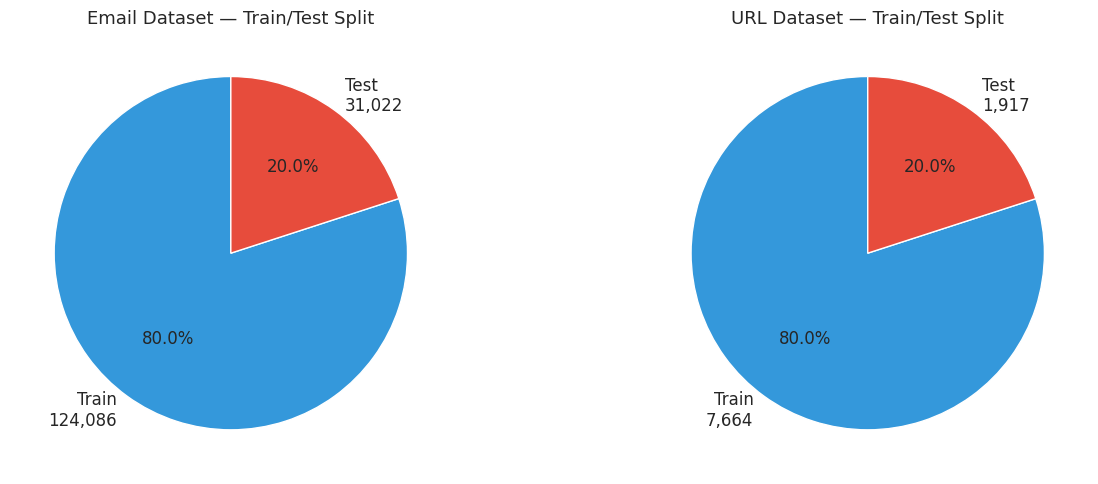

6.3 — Train/test split pie charts plotted


6.4 — Split Summary
Email dataset
  X_email_train : (124086, 5013)
  X_email_test  : (31022, 5013)
  y_email_train : (124086,)
  y_email_test  : (31022,)

URL dataset
  X_url_train   : (7664, 50)
  X_url_test    : (1917, 50)
  y_url_train   : (7664,)
  y_url_test    : (1917,)

Outputs ready for Section 7:
  X_email_train, X_email_test, y_email_train, y_email_test
  X_url_train, X_url_test, y_url_train, y_url_test


In [9]:
# ============================================================
# SECTION 6 — TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ──────────────────────────────────────────────────────────
# 6.1 EMAIL DATASET SPLIT
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("6.1 — Email Dataset Train-Test Split")
print("=" * 55)

# stratify=y_email ensures label ratio is preserved
# in both train and test sets
# random_state=42 for reproducibility
X_email_train, X_email_test, y_email_train, y_email_test = train_test_split(
    X_email,
    y_email,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_email
)

print(f"Total samples          : {X_email.shape[0]:,}")
print(f"Training samples       : {X_email_train.shape[0]:,}")
print(f"Testing samples        : {X_email_test.shape[0]:,}")
print(f"Feature count          : {X_email_train.shape[1]:,}")
print(f"\nTraining label split:")
unique, counts = np.unique(y_email_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u} : {c:,} ({c/len(y_email_train)*100:.1f}%)")
print(f"\nTesting label split:")
unique, counts = np.unique(y_email_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u} : {c:,} ({c/len(y_email_test)*100:.1f}%)")

# ──────────────────────────────────────────────────────────
# 6.2 URL DATASET SPLIT
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("6.2 — URL Dataset Train-Test Split")
print("=" * 55)

X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    url_fe,
    y_url,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_url
)

print(f"Total samples          : {url_fe.shape[0]:,}")
print(f"Training samples       : {X_url_train.shape[0]:,}")
print(f"Testing samples        : {X_url_test.shape[0]:,}")
print(f"Feature count          : {X_url_train.shape[1]:,}")
print(f"\nTraining label split:")
unique, counts = np.unique(y_url_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u} : {c:,} ({c/len(y_url_train)*100:.1f}%)")
print(f"\nTesting label split:")
unique, counts = np.unique(y_url_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u} : {c:,} ({c/len(y_url_test)*100:.1f}%)")

# ──────────────────────────────────────────────────────────
# 6.3 VISUALIZE SPLIT PROPORTIONS
# ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Email split visualization
email_split_data = {
    'Train' : X_email_train.shape[0],
    'Test'  : X_email_test.shape[0]
}
axes[0].pie(
    email_split_data.values(),
    labels    = [f"{k}\n{v:,}" for k, v in email_split_data.items()],
    colors    = ['#3498db', '#e74c3c'],
    autopct   = '%1.1f%%',
    startangle= 90,
    textprops = {'fontsize': 12}
)
axes[0].set_title('Email Dataset — Train/Test Split', fontsize=13)

# URL split visualization
url_split_data = {
    'Train' : X_url_train.shape[0],
    'Test'  : X_url_test.shape[0]
}
axes[1].pie(
    url_split_data.values(),
    labels    = [f"{k}\n{v:,}" for k, v in url_split_data.items()],
    colors    = ['#3498db', '#e74c3c'],
    autopct   = '%1.1f%%',
    startangle= 90,
    textprops = {'fontsize': 12}
)
axes[1].set_title('URL Dataset — Train/Test Split', fontsize=13)

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("6.3 — Train/test split pie charts plotted")

# ──────────────────────────────────────────────────────────
# 6.4 SPLIT SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("6.4 — Split Summary")
print("=" * 55)
print(f"Email dataset")
print(f"  X_email_train : {X_email_train.shape}")
print(f"  X_email_test  : {X_email_test.shape}")
print(f"  y_email_train : {y_email_train.shape}")
print(f"  y_email_test  : {y_email_test.shape}")
print(f"\nURL dataset")
print(f"  X_url_train   : {X_url_train.shape}")
print(f"  X_url_test    : {X_url_test.shape}")
print(f"  y_url_train   : {y_url_train.shape}")
print(f"  y_url_test    : {y_url_test.shape}")
print(f"\nOutputs ready for Section 7:")
print(f"  X_email_train, X_email_test, y_email_train, y_email_test")
print(f"  X_url_train, X_url_test, y_url_train, y_url_test")

## Model Training

In [10]:
import xgboost as xgb
import lightgbm as lgb

print(f"XGBoost version  : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")
print("Both libraries ready")

XGBoost version  : 3.2.0
LightGBM version : 4.6.0
Both libraries ready


7.0 — Data Preparation for GPU
Email train type      : <class 'scipy.sparse._csr.csr_matrix'>
Email train dtype     : float32
URL train type        : <class 'numpy.ndarray'>
URL train dtype       : float32
y_email_train dtype   : int32
y_url_train dtype     : int32
GPU data ready


7.1 — Email Model Training

Training XGBoost (GPU)...
[0]	train-logloss:0.67095	train-auc:0.83346	eval-logloss:0.67118	eval-auc:0.82995
[50]	train-logloss:0.29960	train-auc:0.97835	eval-logloss:0.30404	eval-auc:0.97634
[100]	train-logloss:0.20925	train-auc:0.98853	eval-logloss:0.21540	eval-auc:0.98681
[150]	train-logloss:0.16673	train-auc:0.99236	eval-logloss:0.17408	eval-auc:0.99071
[200]	train-logloss:0.14179	train-auc:0.99446	eval-logloss:0.14985	eval-auc:0.99297
[250]	train-logloss:0.12363	train-auc:0.99576	eval-logloss:0.13232	eval-auc:0.99436
[299]	train-logloss:0.11065	train-auc:0.99654	eval-logloss:0.11969	eval-auc:0.99527

  XGBoost training time : 19.9s

Training LightGBM (GPU)...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 20 rounds
[50]	train's binary_logloss: 0.161931	train's auc: 0.994482	eval's binary_logloss: 0.16841	eval's auc: 0.993257
[100]	train's binary_logloss: 0.0823932	train's auc: 0.997754	eval's binary_logloss: 0.0916039	eval's auc: 0.996832
[150]	train's binary_logloss: 0.0520878	train's auc: 0.999082	eval's binary_logloss: 0.0627656	eval's auc: 0.998358
[200]	train's binary_logloss: 0.0368519	train's auc: 0.999585	eval's binary_logloss: 0.048645	eval's auc: 0.998976
[250]	train's binary_logloss: 0.0277323	train's auc: 0.999797	eval's binary_logloss: 0.0404672	eval's auc: 0.999272
[300]	train's binary_logloss: 0.0216454	train's auc: 0.999899	eval's binary_logloss: 0.0349239	eval's auc: 0.999448
Did not meet early stopping. Best iteration is:
[300]	train's binary_logloss: 0.0216454	train's auc: 0.999899	eval's binary_logloss: 0.0349239	eval's auc: 0.999448

  LightGBM training time : 214.5s

--- Email Model Comparison on Test Set ---

  XG

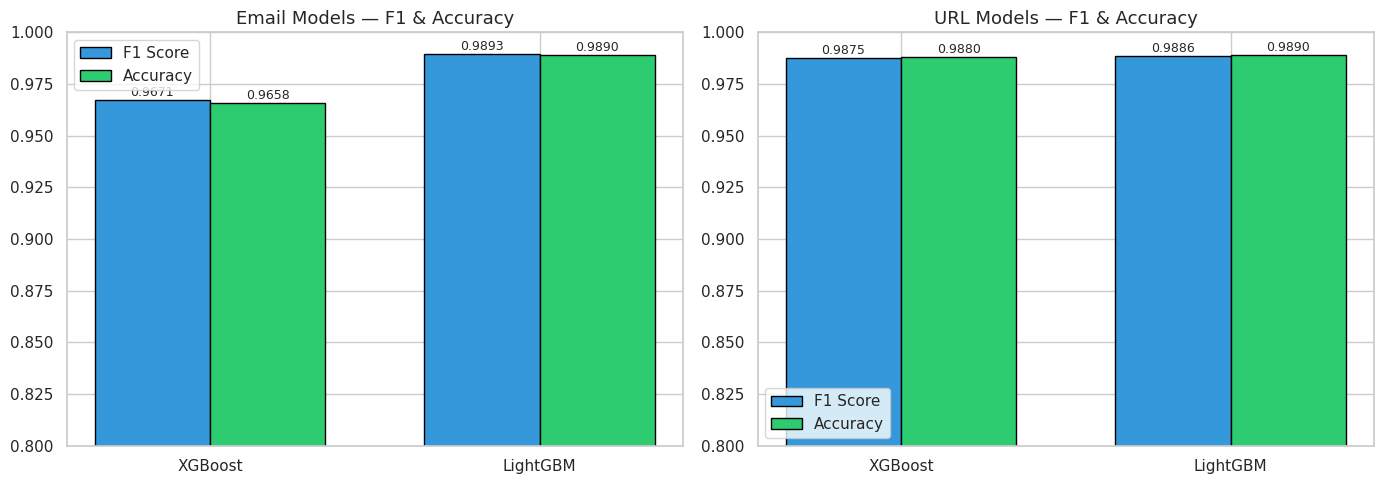

7.3 — Model comparison plotted


7.4 — Training Summary
Email model results:
  XGBoost  — F1: 0.9671 | Accuracy: 0.9658
  LightGBM — F1: 0.9893 | Accuracy: 0.9890

URL model results:
  XGBoost  — F1: 0.9875 | Accuracy: 0.9880
  LightGBM — F1: 0.9886 | Accuracy: 0.9890

Selected for evaluation:
  Email model : LightGBM (F1=0.9893)
  URL model   : LightGBM   (F1=0.9886)

Outputs ready for Section 8:
  best_email_model, best_email_name, best_email_type
  best_url_model,   best_url_name,   best_url_type
  dtrain_email, dtest_email
  dtrain_url,   dtest_url


In [11]:
# ============================================================
# SECTION 7 — MODEL TRAINING (GPU ACCELERATED)
# ============================================================

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import scipy.sparse as sp
import time

# ──────────────────────────────────────────────────────────
# 7.0 CONVERT SPARSE MATRIX FOR GPU COMPATIBILITY
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("7.0 — Data Preparation for GPU")
print("=" * 55)

# Email — sparse matrix, convert to float32
X_email_train_gpu = X_email_train.astype('float32')
X_email_test_gpu  = X_email_test.astype('float32')

# URL — DataFrame, convert values to float32
X_url_train_gpu   = X_url_train.values.astype('float32')
X_url_test_gpu    = X_url_test.values.astype('float32')

# Labels — convert to int32
y_email_train_gpu = y_email_train.astype('int32')
y_email_test_gpu  = y_email_test.astype('int32')
y_url_train_gpu   = y_url_train.astype('int32').values
y_url_test_gpu    = y_url_test.astype('int32').values

print(f"Email train type      : {type(X_email_train_gpu)}")
print(f"Email train dtype     : {X_email_train_gpu.dtype}")
print(f"URL train type        : {type(X_url_train_gpu)}")
print(f"URL train dtype       : {X_url_train_gpu.dtype}")
print(f"y_email_train dtype   : {y_email_train_gpu.dtype}")
print(f"y_url_train dtype     : {y_url_train_gpu.dtype}")
print(f"GPU data ready")
# ──────────────────────────────────────────────────────────
# 7.1 EMAIL MODEL TRAINING
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("7.1 — Email Model Training")
print("=" * 55)

# ── Model 1: XGBoost with DMatrix (best sparse GPU support)
print("\nTraining XGBoost (GPU)...")
start = time.time()

# Convert to DMatrix — XGBoost's native format
# handles sparse matrices most efficiently on GPU
dtrain_email = xgb.DMatrix(X_email_train_gpu, label=y_email_train_gpu)
dtest_email  = xgb.DMatrix(X_email_test_gpu,  label=y_email_test_gpu)

xgb_email_params = {
    'device'          : 'cuda',
    'objective'       : 'binary:logistic',
    'eval_metric'     : ['logloss', 'auc'],
    'max_depth'       : 6,
    'learning_rate'   : 0.05,
    'n_estimators'    : 300,
    'subsample'       : 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 5,
    'gamma'           : 0.1,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'scale_pos_weight': 1,
    'seed'            : 42
}

# Early stopping prevents overfitting automatically
xgb_email_model = xgb.train(
    xgb_email_params,
    dtrain_email,
    num_boost_round    = 300,
    evals              = [(dtrain_email, 'train'), (dtest_email, 'eval')],
    early_stopping_rounds = 20,
    verbose_eval       = 50
)

elapsed = time.time() - start
print(f"\n  XGBoost training time : {elapsed:.1f}s")

# ── Model 2: LightGBM (native sparse + GPU support) ───────
print("\nTraining LightGBM (GPU)...")
start = time.time()

lgb_email_params = {
    'device'          : 'gpu',
    'objective'       : 'binary',
    'metric'          : ['binary_logloss', 'auc'],
    'boosting_type'   : 'gbdt',
    'num_leaves'      : 63,
    'max_depth'       : -1,
    'learning_rate'   : 0.05,
    'n_estimators'    : 300,
    'subsample'       : 0.8,
    'colsample_bytree': 0.7,
    'min_child_samples': 20,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'verbose'         : -1,
    'random_state'    : 42
}

lgb_email_train = lgb.Dataset(X_email_train_gpu, label=y_email_train_gpu)
lgb_email_val   = lgb.Dataset(X_email_test_gpu,  label=y_email_test_gpu,
                               reference=lgb_email_train)

callbacks = [
    lgb.early_stopping(stopping_rounds=20, verbose=True),
    lgb.log_evaluation(period=50)
]

lgb_email_model = lgb.train(
    lgb_email_params,
    lgb_email_train,
    num_boost_round   = 300,
    valid_sets        = [lgb_email_train, lgb_email_val],
    valid_names       = ['train', 'eval'],
    callbacks         = callbacks
)

elapsed = time.time() - start
print(f"\n  LightGBM training time : {elapsed:.1f}s")

# ── Compare both models on test set ───────────────────────
print("\n--- Email Model Comparison on Test Set ---")

# XGBoost predictions
xgb_email_probs = xgb_email_model.predict(dtest_email)
xgb_email_preds = (xgb_email_probs > 0.5).astype(int)
xgb_email_f1    = f1_score(y_email_test_gpu, xgb_email_preds)
xgb_email_acc   = (xgb_email_preds == y_email_test_gpu).mean()

# LightGBM predictions
lgb_email_probs = lgb_email_model.predict(X_email_test_gpu)
lgb_email_preds = (lgb_email_probs > 0.5).astype(int)
lgb_email_f1    = f1_score(y_email_test_gpu, lgb_email_preds)
lgb_email_acc   = (lgb_email_preds == y_email_test_gpu).mean()

print(f"\n  XGBoost  — Accuracy: {xgb_email_acc:.4f} | F1: {xgb_email_f1:.4f}")
print(f"  LightGBM — Accuracy: {lgb_email_acc:.4f} | F1: {lgb_email_f1:.4f}")

# Select best email model
if xgb_email_f1 >= lgb_email_f1:
    best_email_model      = xgb_email_model
    best_email_name       = 'XGBoost'
    best_email_type       = 'xgboost'
    best_email_f1         = xgb_email_f1
else:
    best_email_model      = lgb_email_model
    best_email_name       = 'LightGBM'
    best_email_type       = 'lightgbm'
    best_email_f1         = lgb_email_f1

print(f"\nBest email model      : {best_email_name}")
print(f"Best email F1         : {best_email_f1:.4f}")

# ── Overfitting check ──────────────────────────────────────
if best_email_type == 'xgboost':
    train_preds = (xgb_email_model.predict(dtrain_email) > 0.5).astype(int)
else:
    train_preds = (lgb_email_model.predict(X_email_train_gpu) > 0.5).astype(int)

train_f1 = f1_score(y_email_train_gpu, train_preds)
print(f"\nOverfitting check (email):")
print(f"  Train F1            : {train_f1:.4f}")
print(f"  Test  F1            : {best_email_f1:.4f}")
print(f"  Difference          : {abs(train_f1 - best_email_f1):.4f}")
if abs(train_f1 - best_email_f1) < 0.03:
    print(f"  Status              : GOOD — no overfitting detected")
elif abs(train_f1 - best_email_f1) < 0.06:
    print(f"  Status              : ACCEPTABLE — minor gap")
else:
    print(f"  Status              : WARNING — possible overfitting")

# ──────────────────────────────────────────────────────────
# 7.2 URL MODEL TRAINING
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("7.2 — URL Model Training")
print("=" * 55)

# ── Model 1: XGBoost ──────────────────────────────────────
print("\nTraining XGBoost (GPU)...")
start = time.time()

dtrain_url = xgb.DMatrix(X_url_train_gpu, label=y_url_train_gpu)
dtest_url  = xgb.DMatrix(X_url_test_gpu,  label=y_url_test_gpu)

xgb_url_params = {
    'device'          : 'cuda',
    'objective'       : 'binary:logistic',
    'eval_metric'     : ['logloss', 'auc'],
    'max_depth'       : 6,
    'learning_rate'   : 0.05,
    'subsample'       : 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 5,
    'gamma'           : 0.1,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'seed'            : 42
}

xgb_url_model = xgb.train(
    xgb_url_params,
    dtrain_url,
    num_boost_round       = 300,
    evals                 = [(dtrain_url, 'train'), (dtest_url, 'eval')],
    early_stopping_rounds = 20,
    verbose_eval          = 50
)

elapsed = time.time() - start
print(f"\n  XGBoost training time : {elapsed:.1f}s")

# ── Model 2: LightGBM ─────────────────────────────────────
print("\nTraining LightGBM (GPU)...")
start = time.time()

lgb_url_params = {
    'device'           : 'gpu',
    'objective'        : 'binary',
    'metric'           : ['binary_logloss', 'auc'],
    'boosting_type'    : 'gbdt',
    'num_leaves'       : 63,
    'max_depth'        : -1,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.7,
    'min_child_samples': 20,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'verbose'          : -1,
    'random_state'     : 42
}

lgb_url_train = lgb.Dataset(X_url_train_gpu, label=y_url_train_gpu)
lgb_url_val   = lgb.Dataset(X_url_test_gpu,  label=y_url_test_gpu,
                              reference=lgb_url_train)

lgb_url_model = lgb.train(
    lgb_url_params,
    lgb_url_train,
    num_boost_round   = 300,
    valid_sets        = [lgb_url_train, lgb_url_val],
    valid_names       = ['train', 'eval'],
    callbacks         = callbacks
)

elapsed = time.time() - start
print(f"\n  LightGBM training time : {elapsed:.1f}s")

# ── Compare both models on test set ───────────────────────
print("\n--- URL Model Comparison on Test Set ---")

xgb_url_probs = xgb_url_model.predict(dtest_url)
xgb_url_preds = (xgb_url_probs > 0.5).astype(int)
xgb_url_f1    = f1_score(y_url_test_gpu, xgb_url_preds)
xgb_url_acc   = (xgb_url_preds == y_url_test_gpu).mean()

lgb_url_probs = lgb_url_model.predict(X_url_test_gpu)
lgb_url_preds = (lgb_url_probs > 0.5).astype(int)
lgb_url_f1    = f1_score(y_url_test_gpu, lgb_url_preds)
lgb_url_acc   = (lgb_url_preds == y_url_test_gpu).mean()

print(f"\n  XGBoost  — Accuracy: {xgb_url_acc:.4f} | F1: {xgb_url_f1:.4f}")
print(f"  LightGBM — Accuracy: {lgb_url_acc:.4f} | F1: {lgb_url_f1:.4f}")

if xgb_url_f1 >= lgb_url_f1:
    best_url_model  = xgb_url_model
    best_url_name   = 'XGBoost'
    best_url_type   = 'xgboost'
    best_url_f1     = xgb_url_f1
else:
    best_url_model  = lgb_url_model
    best_url_name   = 'LightGBM'
    best_url_type   = 'lightgbm'
    best_url_f1     = lgb_url_f1

print(f"\nBest URL model        : {best_url_name}")
print(f"Best URL F1           : {best_url_f1:.4f}")

# ── Overfitting check ──────────────────────────────────────
if best_url_type == 'xgboost':
    train_preds_url = (xgb_url_model.predict(dtrain_url) > 0.5).astype(int)
else:
    train_preds_url = (lgb_url_model.predict(X_url_train_gpu) > 0.5).astype(int)

train_f1_url = f1_score(y_url_train_gpu, train_preds_url)
print(f"\nOverfitting check (URL):")
print(f"  Train F1            : {train_f1_url:.4f}")
print(f"  Test  F1            : {best_url_f1:.4f}")
print(f"  Difference          : {abs(train_f1_url - best_url_f1):.4f}")
if abs(train_f1_url - best_url_f1) < 0.03:
    print(f"  Status              : GOOD — no overfitting detected")
elif abs(train_f1_url - best_url_f1) < 0.06:
    print(f"  Status              : ACCEPTABLE — minor gap")
else:
    print(f"  Status              : WARNING — possible overfitting")

# ──────────────────────────────────────────────────────────
# 7.3 CV SCORE COMPARISON PLOT
# ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Email model comparison
email_names = ['XGBoost', 'LightGBM']
email_f1s   = [xgb_email_f1, lgb_email_f1]
email_accs  = [xgb_email_acc, lgb_email_acc]

x = np.arange(len(email_names))
w = 0.35
axes[0].bar(x - w/2, email_f1s,  w, label='F1 Score',  color='#3498db', edgecolor='black')
axes[0].bar(x + w/2, email_accs, w, label='Accuracy',  color='#2ecc71', edgecolor='black')
axes[0].set_title('Email Models — F1 & Accuracy', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(email_names)
axes[0].set_ylim(0.8, 1.0)
axes[0].legend()
for i, (f1, acc) in enumerate(zip(email_f1s, email_accs)):
    axes[0].text(i - w/2, f1  + 0.002, f'{f1:.4f}',  ha='center', fontsize=9)
    axes[0].text(i + w/2, acc + 0.002, f'{acc:.4f}', ha='center', fontsize=9)

# URL model comparison
url_names = ['XGBoost', 'LightGBM']
url_f1s   = [xgb_url_f1, lgb_url_f1]
url_accs  = [xgb_url_acc, lgb_url_acc]

x = np.arange(len(url_names))
axes[1].bar(x - w/2, url_f1s,  w, label='F1 Score', color='#3498db', edgecolor='black')
axes[1].bar(x + w/2, url_accs, w, label='Accuracy', color='#2ecc71', edgecolor='black')
axes[1].set_title('URL Models — F1 & Accuracy', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(url_names)
axes[1].set_ylim(0.8, 1.0)
axes[1].legend()
for i, (f1, acc) in enumerate(zip(url_f1s, url_accs)):
    axes[1].text(i - w/2, f1  + 0.002, f'{f1:.4f}',  ha='center', fontsize=9)
    axes[1].text(i + w/2, acc + 0.002, f'{acc:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("7.3 — Model comparison plotted")

# ──────────────────────────────────────────────────────────
# 7.4 TRAINING SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("7.4 — Training Summary")
print("=" * 55)
print(f"Email model results:")
print(f"  XGBoost  — F1: {xgb_email_f1:.4f} | Accuracy: {xgb_email_acc:.4f}")
print(f"  LightGBM — F1: {lgb_email_f1:.4f} | Accuracy: {lgb_email_acc:.4f}")
print(f"\nURL model results:")
print(f"  XGBoost  — F1: {xgb_url_f1:.4f} | Accuracy: {xgb_url_acc:.4f}")
print(f"  LightGBM — F1: {lgb_url_f1:.4f} | Accuracy: {lgb_url_acc:.4f}")
print(f"\nSelected for evaluation:")
print(f"  Email model : {best_email_name} (F1={best_email_f1:.4f})")
print(f"  URL model   : {best_url_name}   (F1={best_url_f1:.4f})")
print(f"\nOutputs ready for Section 8:")
print(f"  best_email_model, best_email_name, best_email_type")
print(f"  best_url_model,   best_url_name,   best_url_type")
print(f"  dtrain_email, dtest_email")
print(f"  dtrain_url,   dtest_url")

## MODEL EVALUATION

8.0 — Generating Predictions
Email predictions generated : 31,022
URL predictions generated   : 1,917


8.1 — Core Metrics (Accuracy, Precision, Recall, F1)
               Accuracy  Precision  Recall  F1 Score  ROC-AUC  Avg Prec
Model                                                                  
Email — Train    0.9959     0.9939  0.9981    0.9960   0.9999    0.9999
Email — Test     0.9890     0.9867  0.9919    0.9893   0.9994    0.9995
URL — Train      1.0000     1.0000  1.0000    1.0000   1.0000    1.0000
URL — Test       0.9890     0.9848  0.9924    0.9886   0.9996    0.9996

Overfitting Gap (Train F1 - Test F1):
  Email model : 0.0067 GOOD
  URL model   : 0.0114   GOOD


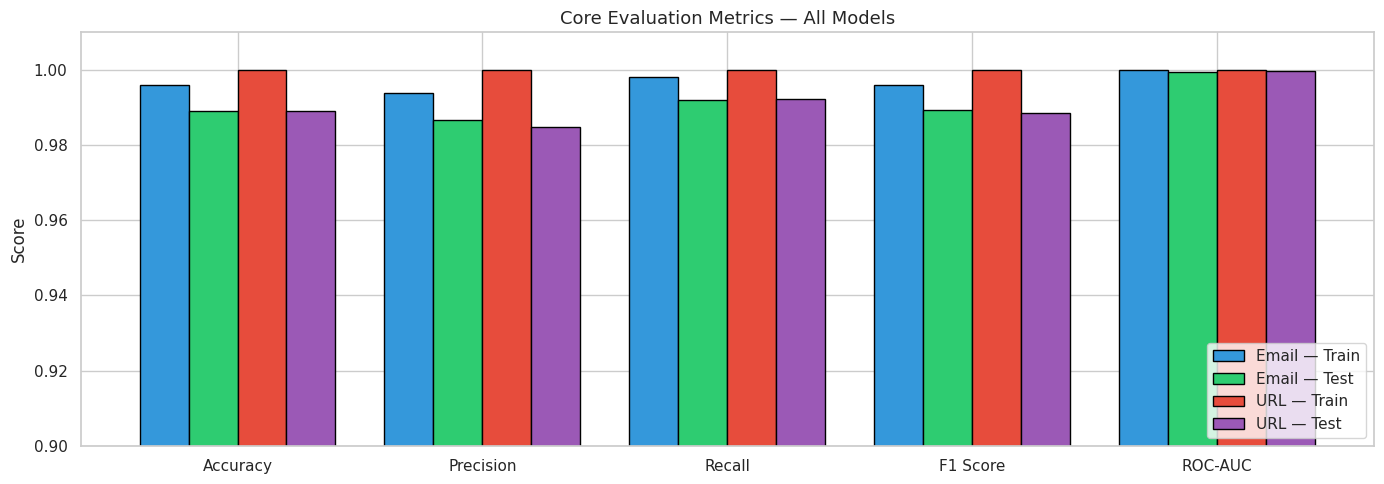

8.1 — Core metrics plotted


8.2 — Confusion Matrix


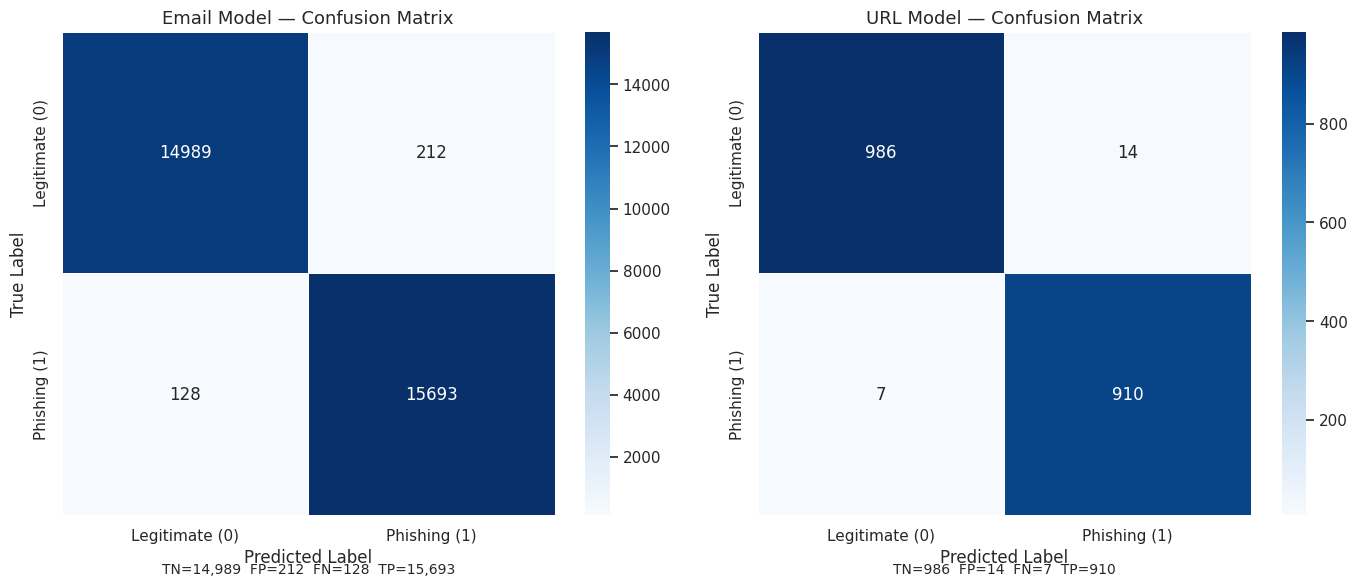


Email model:
  True Negatives  (correctly caught legitimate) : 14,989
  False Positives (legitimate flagged as phish) : 212
  False Negatives (phishing missed)             : 128
  True Positives  (correctly caught phishing)   : 15,693

URL model:
  True Negatives  (correctly caught legitimate) : 986
  False Positives (legitimate flagged as phish) : 14
  False Negatives (phishing missed)             : 7
  True Positives  (correctly caught phishing)   : 910
8.2 — Confusion matrices plotted


8.3 — ROC Curve (AUC)

Email Model:
  AUC Score       : 0.9994

URL Model:
  AUC Score       : 0.9996


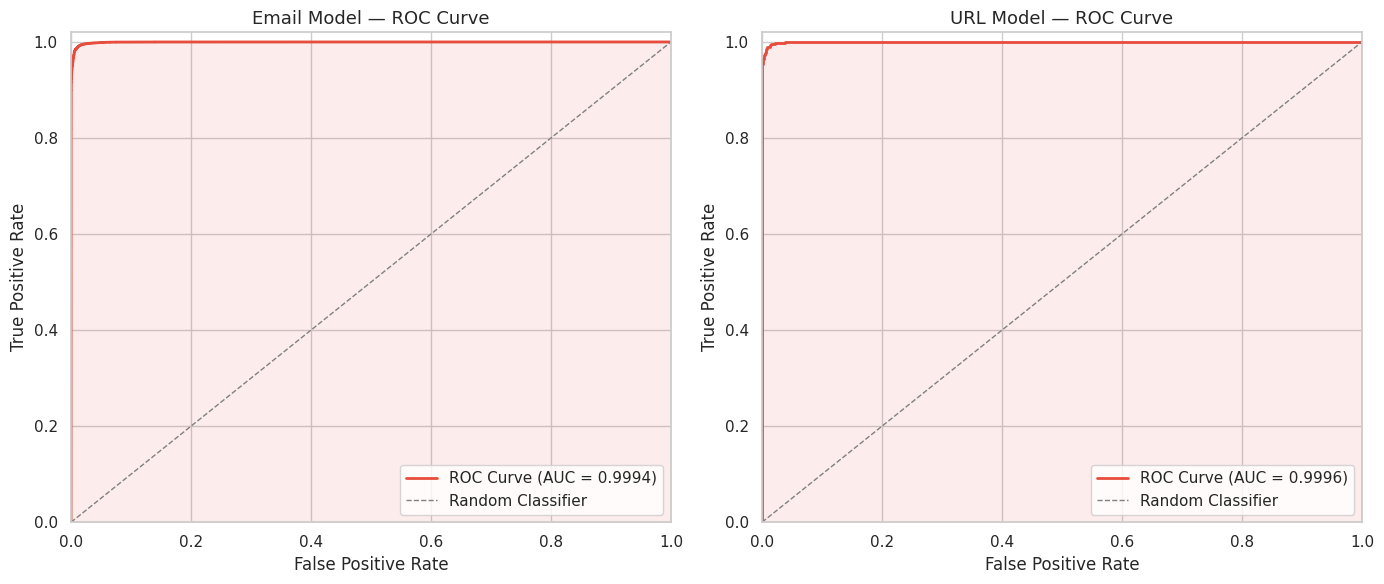

8.3 — ROC curves plotted


8.4 — Precision-Recall Curve

Email Model:
  Average Precision : 0.9995

URL Model:
  Average Precision : 0.9996


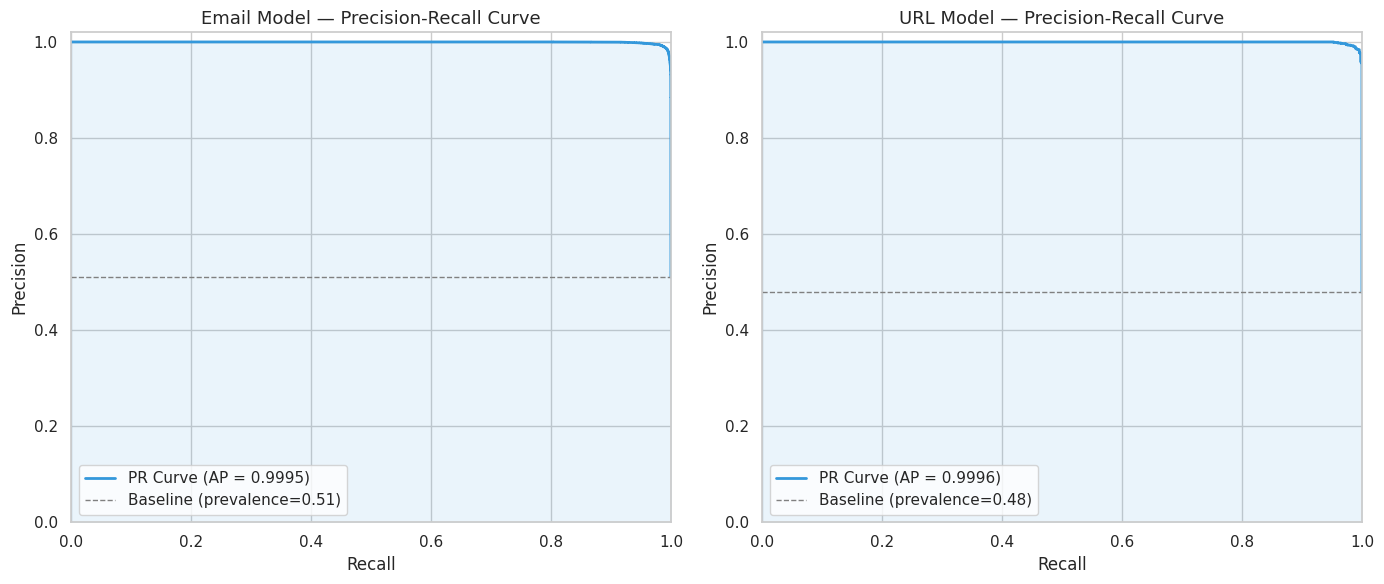

8.4 — Precision-Recall curves plotted


8.5 — Feature Importance


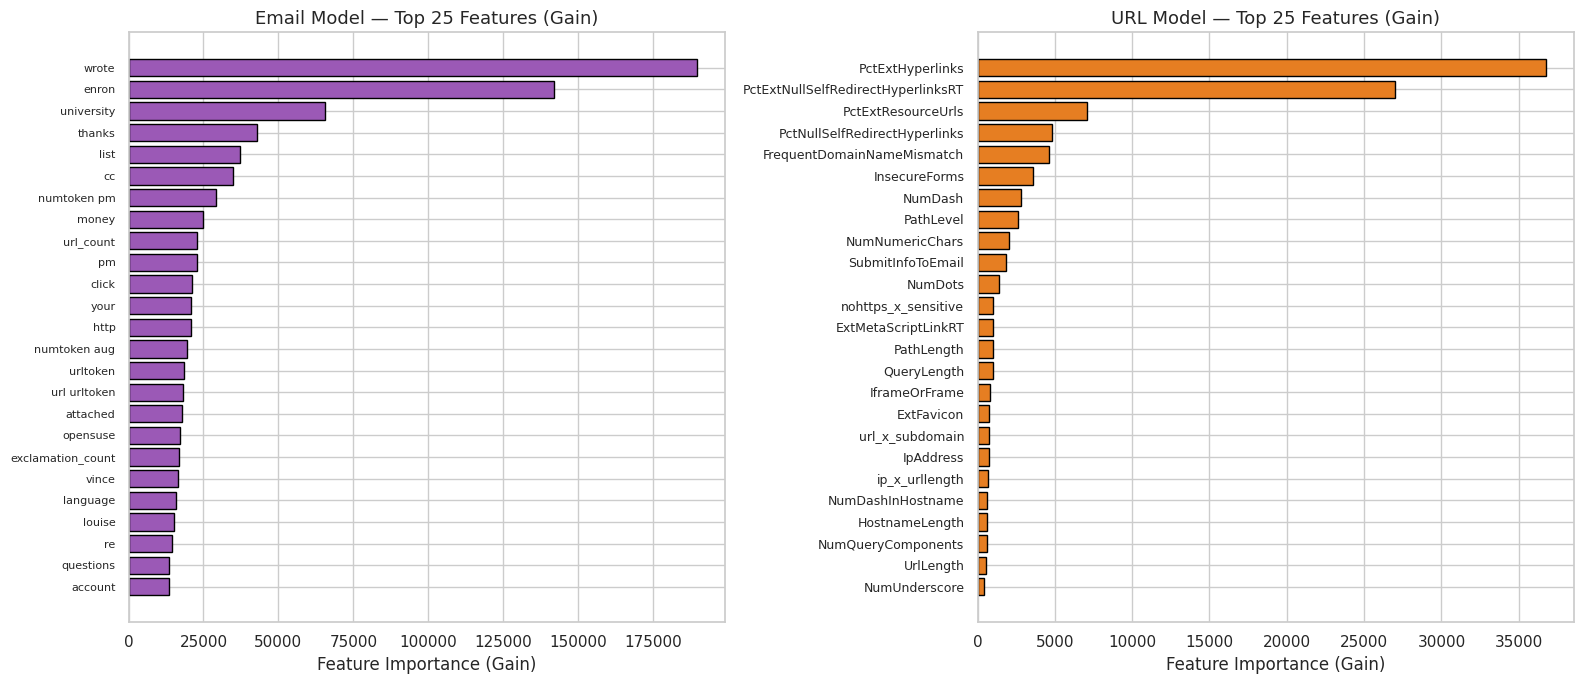


Email model — Top 10 features:
    feature    importance
      wrote 189579.095858
      enron 142029.055070
 university  65701.196509
     thanks  42887.246284
       list  37272.195986
         cc  34956.877548
numtoken pm  29018.845131
      money  24701.969804
  url_count  23000.076836
         pm  22747.309161

URL model — Top 10 features:
                           feature   importance
                  PctExtHyperlinks 36735.134497
PctExtNullSelfRedirectHyperlinksRT 26978.032569
                PctExtResourceUrls  7059.535413
     PctNullSelfRedirectHyperlinks  4820.901366
        FrequentDomainNameMismatch  4607.906389
                     InsecureForms  3611.076161
                           NumDash  2817.855234
                         PathLevel  2594.771096
                   NumNumericChars  2060.749461
                 SubmitInfoToEmail  1815.022336
8.5 — Feature importance plotted


8.6 — Prediction Probability Distribution


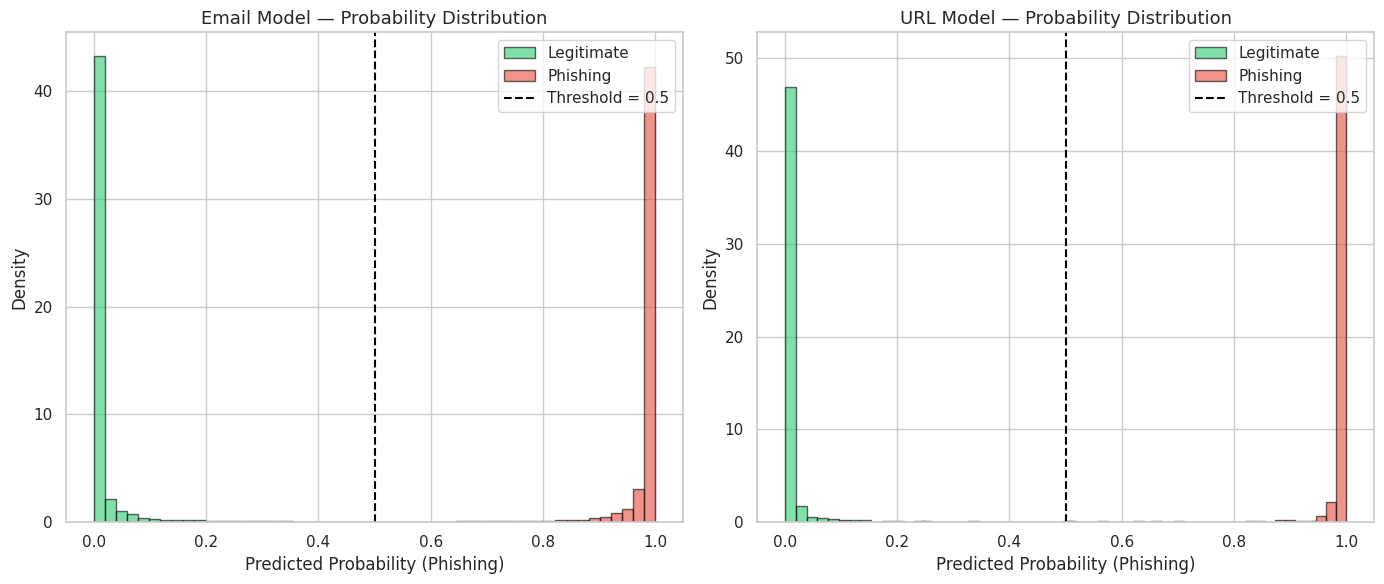


Email model confidence:
  High confidence (>0.9 or <0.1) : 94.4% of predictions
  Uncertain (0.4 - 0.6)          : 0.7% of predictions

URL model confidence:
  High confidence (>0.9 or <0.1) : 96.4% of predictions
  Uncertain (0.4 - 0.6)          : 0.7% of predictions
8.6 — Probability distributions plotted


8.7 — Full Classification Report

Email Model:
              precision    recall  f1-score   support

  Legitimate     0.9915    0.9861    0.9888     15201
    Phishing     0.9867    0.9919    0.9893     15821

    accuracy                         0.9890     31022
   macro avg     0.9891    0.9890    0.9890     31022
weighted avg     0.9891    0.9890    0.9890     31022


URL Model:
              precision    recall  f1-score   support

  Legitimate     0.9930    0.9860    0.9895      1000
    Phishing     0.9848    0.9924    0.9886       917

    accuracy                         0.9890      1917
   macro avg     0.9889    0.9892    0.9890      1917
weighted avg     0.9891    0.9

In [12]:
# ============================================================
# SECTION 8 — MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import matplotlib.gridspec as gridspec

# ──────────────────────────────────────────────────────────
# 8.0 GENERATE PREDICTIONS
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("8.0 — Generating Predictions")
print("=" * 55)

# Email model predictions
lgb_email_probs_test  = best_email_model.predict(X_email_test_gpu)
lgb_email_preds_test  = (lgb_email_probs_test > 0.5).astype(int)
lgb_email_probs_train = best_email_model.predict(X_email_train_gpu)
lgb_email_preds_train = (lgb_email_probs_train > 0.5).astype(int)

# URL model predictions
lgb_url_probs_test    = best_url_model.predict(X_url_test_gpu)
lgb_url_preds_test    = (lgb_url_probs_test > 0.5).astype(int)
lgb_url_probs_train   = best_url_model.predict(X_url_train_gpu)
lgb_url_preds_train   = (lgb_url_probs_train > 0.5).astype(int)

print(f"Email predictions generated : {len(lgb_email_preds_test):,}")
print(f"URL predictions generated   : {len(lgb_url_preds_test):,}")

# ──────────────────────────────────────────────────────────
# 8.1 EVALUATION PARAMETER 1 — CORE METRICS TABLE
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.1 — Core Metrics (Accuracy, Precision, Recall, F1)")
print("=" * 55)

def compute_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1 Score'  : f1_score(y_true, y_pred),
        'ROC-AUC'   : roc_auc_score(y_true, y_prob),
        'Avg Prec'  : average_precision_score(y_true, y_prob)
    }

email_train_metrics = compute_metrics(
    y_email_train_gpu, lgb_email_preds_train,
    lgb_email_probs_train, 'Email — Train'
)
email_test_metrics  = compute_metrics(
    y_email_test_gpu, lgb_email_preds_test,
    lgb_email_probs_test, 'Email — Test'
)
url_train_metrics   = compute_metrics(
    y_url_train_gpu, lgb_url_preds_train,
    lgb_url_probs_train, 'URL — Train'
)
url_test_metrics    = compute_metrics(
    y_url_test_gpu, lgb_url_preds_test,
    lgb_url_probs_test, 'URL — Test'
)

metrics_df = pd.DataFrame([
    email_train_metrics,
    email_test_metrics,
    url_train_metrics,
    url_test_metrics
]).set_index('Model')

print(metrics_df.round(4).to_string())

# ── Overfitting gap ────────────────────────────────────────
email_gap = abs(email_train_metrics['F1 Score'] - email_test_metrics['F1 Score'])
url_gap   = abs(url_train_metrics['F1 Score']   - url_test_metrics['F1 Score'])

print(f"\nOverfitting Gap (Train F1 - Test F1):")
print(f"  Email model : {email_gap:.4f} {'GOOD' if email_gap < 0.03 else 'WARNING'}")
print(f"  URL model   : {url_gap:.4f}   {'GOOD' if url_gap   < 0.03 else 'WARNING'}")

# ── Plot core metrics ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
metrics_plot = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
x     = np.arange(len(metrics_plot.columns))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
labels = metrics_plot.index.tolist()

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.bar(x + i * width, metrics_plot.loc[label], width,
           label=label, color=color, edgecolor='black')

ax.set_title('Core Evaluation Metrics — All Models', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot.columns)
ax.set_ylim(0.90, 1.01)
ax.legend(loc='lower right')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('core_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("8.1 — Core metrics plotted")

# ──────────────────────────────────────────────────────────
# 8.2 EVALUATION PARAMETER 2 — CONFUSION MATRIX
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.2 — Confusion Matrix")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, title in [
    (axes[0], y_email_test_gpu, lgb_email_preds_test, 'Email Model — Confusion Matrix'),
    (axes[1], y_url_test_gpu,   lgb_url_preds_test,   'URL Model — Confusion Matrix')
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        ax         = ax,
        linewidths = 0.5,
        cbar       = True,
        xticklabels= ['Legitimate (0)', 'Phishing (1)'],
        yticklabels= ['Legitimate (0)', 'Phishing (1)']
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # Annotate TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
            ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print raw values
for y_true, y_pred, name in [
    (y_email_test_gpu, lgb_email_preds_test, 'Email'),
    (y_url_test_gpu,   lgb_url_preds_test,   'URL')
]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{name} model:")
    print(f"  True Negatives  (correctly caught legitimate) : {tn:,}")
    print(f"  False Positives (legitimate flagged as phish) : {fp:,}")
    print(f"  False Negatives (phishing missed)             : {fn:,}")
    print(f"  True Positives  (correctly caught phishing)   : {tp:,}")
print("8.2 — Confusion matrices plotted")

# ──────────────────────────────────────────────────────────
# 8.3 EVALUATION PARAMETER 3 — ROC CURVE
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.3 — ROC Curve (AUC)")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_prob, name in [
    (axes[0], y_email_test_gpu, lgb_email_probs_test, 'Email Model'),
    (axes[1], y_url_test_gpu,   lgb_url_probs_test,   'URL Model')
]:
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, color='#e74c3c', lw=2,
            label=f'ROC Curve (AUC = {auc_score:.4f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1,
            linestyle='--', label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    ax.set_title(f'{name} — ROC Curve', fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    print(f"\n{name}:")
    print(f"  AUC Score       : {auc_score:.4f}")

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("8.3 — ROC curves plotted")

# ──────────────────────────────────────────────────────────
# 8.4 EVALUATION PARAMETER 4 — PRECISION-RECALL CURVE
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.4 — Precision-Recall Curve")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_prob, name in [
    (axes[0], y_email_test_gpu, lgb_email_probs_test, 'Email Model'),
    (axes[1], y_url_test_gpu,   lgb_url_probs_test,   'URL Model')
]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    avg_precision = average_precision_score(y_true, y_prob)

    ax.plot(recall, precision, color='#3498db', lw=2,
            label=f'PR Curve (AP = {avg_precision:.4f})')
    ax.fill_between(recall, precision, alpha=0.1, color='#3498db')
    ax.axhline(
        y    = y_true.mean(),
        color= 'gray', lw=1,
        linestyle='--',
        label= f'Baseline (prevalence={y_true.mean():.2f})'
    )
    ax.set_title(f'{name} — Precision-Recall Curve', fontsize=13)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    print(f"\n{name}:")
    print(f"  Average Precision : {avg_precision:.4f}")

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("8.4 — Precision-Recall curves plotted")

# ──────────────────────────────────────────────────────────
# 8.5 EVALUATION PARAMETER 5 — FEATURE IMPORTANCE
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.5 — Feature Importance")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Email model — top 25 features
email_importance = best_email_model.feature_importance(importance_type='gain')

# Feature names — TF-IDF tokens + hand-crafted
tfidf_names      = tfidf.get_feature_names_out().tolist()
hand_feat_names  = [
    'url_count', 'email_count', 'num_count', 'body_length',
    'subject_length', 'word_count', 'avg_word_length',
    'exclamation_count', 'question_count', 'capital_ratio',
    'keyword_count', 'suspicious_subject', 'has_html'
]
email_feat_names = tfidf_names + hand_feat_names

email_imp_df = pd.DataFrame({
    'feature'    : email_feat_names,
    'importance' : email_importance
}).sort_values('importance', ascending=False).head(25)

axes[0].barh(
    email_imp_df['feature'][::-1],
    email_imp_df['importance'][::-1],
    color='#9b59b6', edgecolor='black'
)
axes[0].set_title('Email Model — Top 25 Features (Gain)', fontsize=13)
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].tick_params(axis='y', labelsize=8)

# URL model — top 25 features
url_importance   = best_url_model.feature_importance(importance_type='gain')
url_feat_names   = list(url_fe.columns)

url_imp_df = pd.DataFrame({
    'feature'    : url_feat_names,
    'importance' : url_importance
}).sort_values('importance', ascending=False).head(25)

axes[1].barh(
    url_imp_df['feature'][::-1],
    url_imp_df['importance'][::-1],
    color='#e67e22', edgecolor='black'
)
axes[1].set_title('URL Model — Top 25 Features (Gain)', fontsize=13)
axes[1].set_xlabel('Feature Importance (Gain)')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEmail model — Top 10 features:")
print(email_imp_df[['feature', 'importance']].head(10).to_string(index=False))
print(f"\nURL model — Top 10 features:")
print(url_imp_df[['feature', 'importance']].head(10).to_string(index=False))
print("8.5 — Feature importance plotted")

# ──────────────────────────────────────────────────────────
# 8.6 EVALUATION PARAMETER 6 — PREDICTION PROBABILITY
#     DISTRIBUTION
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.6 — Prediction Probability Distribution")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_prob, name in [
    (axes[0], y_email_test_gpu, lgb_email_probs_test, 'Email Model'),
    (axes[1], y_url_test_gpu,   lgb_url_probs_test,   'URL Model')
]:
    for label, color, lname in [
        (0, '#2ecc71', 'Legitimate'),
        (1, '#e74c3c', 'Phishing')
    ]:
        mask = y_true == label
        ax.hist(
            y_prob[mask],
            bins      = 50,
            alpha     = 0.6,
            color     = color,
            label     = lname,
            edgecolor = 'black',
            density   = True
        )

    ax.axvline(x=0.5, color='black', lw=1.5,
               linestyle='--', label='Threshold = 0.5')
    ax.set_title(f'{name} — Probability Distribution', fontsize=13)
    ax.set_xlabel('Predicted Probability (Phishing)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Confidence analysis
for y_true, y_prob, name in [
    (y_email_test_gpu, lgb_email_probs_test, 'Email'),
    (y_url_test_gpu,   lgb_url_probs_test,   'URL')
]:
    high_conf = ((y_prob > 0.9) | (y_prob < 0.1)).mean() * 100
    uncertain = ((y_prob >= 0.4) & (y_prob <= 0.6)).mean() * 100
    print(f"\n{name} model confidence:")
    print(f"  High confidence (>0.9 or <0.1) : {high_conf:.1f}% of predictions")
    print(f"  Uncertain (0.4 - 0.6)          : {uncertain:.1f}% of predictions")

print("8.6 — Probability distributions plotted")

# ──────────────────────────────────────────────────────────
# 8.7 CLASSIFICATION REPORT
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.7 — Full Classification Report")
print("=" * 55)

for y_true, y_pred, name in [
    (y_email_test_gpu, lgb_email_preds_test, 'Email Model'),
    (y_url_test_gpu,   lgb_url_preds_test,   'URL Model')
]:
    print(f"\n{name}:")
    print(classification_report(
        y_true, y_pred,
        target_names=['Legitimate', 'Phishing'],
        digits=4
    ))

# ──────────────────────────────────────────────────────────
# 8.8 EVALUATION SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("8.8 — Evaluation Summary")
print("=" * 55)
print(metrics_df.round(4).to_string())
print(f"\nGraphs saved:")
print(f"  core_metrics.png")
print(f"  confusion_matrix.png")
print(f"  roc_curve.png")
print(f"  precision_recall_curve.png")
print(f"  feature_importance.png")
print(f"  probability_distribution.png")
print(f"\nOutputs ready for Section 9:")
print(f"  best_email_model — LightGBM email classifier")
print(f"  best_url_model   — LightGBM URL classifier")
print(f"  tfidf            — fitted TF-IDF vectorizer")
print(f"  scaler           — fitted StandardScaler")
print(f"  url_feat_names   — URL feature column names")

## Save Model

In [13]:
# ============================================================
# SECTION 9 — SAVE MODEL
# ============================================================

import joblib
import os
import json

# ──────────────────────────────────────────────────────────
# 9.1 CREATE OUTPUT DIRECTORY
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("9.1 — Creating Output Directory")
print("=" * 55)

SAVE_DIR = '/kaggle/working/phishing_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory : {SAVE_DIR}")

# ──────────────────────────────────────────────────────────
# 9.2 SAVE EMAIL MODEL (LightGBM)
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.2 — Saving Email Model")
print("=" * 55)

# Save LightGBM email model in native format
email_model_path = os.path.join(SAVE_DIR, 'email_model.pkl')
best_email_model.save_model(
    os.path.join(SAVE_DIR, 'email_model.txt')
)

# Also save with joblib for easy loading in Flask
joblib.dump(best_email_model, email_model_path)

print(f"Email model saved  : {email_model_path}")
print(f"Email model (txt)  : {SAVE_DIR}/email_model.txt")

# ──────────────────────────────────────────────────────────
# 9.3 SAVE URL MODEL (LightGBM)
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.3 — Saving URL Model")
print("=" * 55)

url_model_path = os.path.join(SAVE_DIR, 'url_model.pkl')
best_url_model.save_model(
    os.path.join(SAVE_DIR, 'url_model.txt')
)

joblib.dump(best_url_model, url_model_path)

print(f"URL model saved    : {url_model_path}")
print(f"URL model (txt)    : {SAVE_DIR}/url_model.txt")

# ──────────────────────────────────────────────────────────
# 9.4 SAVE TFIDF VECTORIZER
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.4 — Saving TF-IDF Vectorizer")
print("=" * 55)

tfidf_path = os.path.join(SAVE_DIR, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf, tfidf_path)
print(f"TF-IDF saved       : {tfidf_path}")
print(f"Vocabulary size    : {len(tfidf.vocabulary_):,}")

# ──────────────────────────────────────────────────────────
# 9.5 SAVE SCALER
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.5 — Saving StandardScaler")
print("=" * 55)

scaler_path = os.path.join(SAVE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved       : {scaler_path}")

# ──────────────────────────────────────────────────────────
# 9.6 SAVE URL FEATURE NAMES
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.6 — Saving URL Feature Names")
print("=" * 55)

url_feature_names      = list(url_fe.columns)
url_feat_names_path    = os.path.join(SAVE_DIR, 'url_feature_names.pkl')
joblib.dump(url_feature_names, url_feat_names_path)
print(f"URL feature names saved : {url_feat_names_path}")
print(f"Total URL features      : {len(url_feature_names)}")

# ──────────────────────────────────────────────────────────
# 9.7 SAVE MODEL METADATA AS JSON
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.7 — Saving Model Metadata")
print("=" * 55)

metadata = {
    'email_model': {
        'type'              : best_email_name,
        'f1_score'          : round(float(best_email_f1), 4),
        'accuracy'          : round(float(email_test_metrics['Accuracy']), 4),
        'precision'         : round(float(email_test_metrics['Precision']), 4),
        'recall'            : round(float(email_test_metrics['Recall']), 4),
        'roc_auc'           : round(float(email_test_metrics['ROC-AUC']), 4),
        'train_samples'     : int(X_email_train.shape[0]),
        'test_samples'      : int(X_email_test.shape[0]),
        'total_features'    : int(X_email.shape[1]),
        'tfidf_features'    : int(X_tfidf.shape[1]),
        'hand_features'     : int(email_hand_features.shape[1]),
        'model_file'        : 'email_model.pkl',
        'tfidf_file'        : 'tfidf_vectorizer.pkl'
    },
    'url_model': {
        'type'              : best_url_name,
        'f1_score'          : round(float(best_url_f1), 4),
        'accuracy'          : round(float(url_test_metrics['Accuracy']), 4),
        'precision'         : round(float(url_test_metrics['Precision']), 4),
        'recall'            : round(float(url_test_metrics['Recall']), 4),
        'roc_auc'           : round(float(url_test_metrics['ROC-AUC']), 4),
        'train_samples'     : int(X_url_train.shape[0]),
        'test_samples'      : int(X_url_test.shape[0]),
        'total_features'    : int(url_fe.shape[1]),
        'model_file'        : 'url_model.pkl',
        'scaler_file'       : 'scaler.pkl',
        'feature_names_file': 'url_feature_names.pkl'
    },
    'phishing_keywords' : [
        'click', 'verify', 'account', 'password', 'urgent',
        'bank', 'login', 'update', 'confirm', 'secure',
        'winner', 'prize', 'free', 'offer', 'limited',
        'suspend', 'validate', 'expire', 'immediate', 'alert'
    ],
    'subject_keywords'  : [
        'urgent', 'verify', 'suspended', 'winner',
        'congratulations', 'alert', 'confirm', 'free'
    ],
    'threshold'         : 0.5
}

metadata_path = os.path.join(SAVE_DIR, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved     : {metadata_path}")
print(json.dumps(metadata, indent=4))

# ──────────────────────────────────────────────────────────
# 9.8 VERIFY ALL SAVED FILES
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.8 — Verifying Saved Files")
print("=" * 55)

saved_files = os.listdir(SAVE_DIR)
total_size  = 0

for fname in sorted(saved_files):
    fpath = os.path.join(SAVE_DIR, fname)
    fsize = os.path.getsize(fpath)
    total_size += fsize
    print(f"  {fname:<35} {fsize/1024/1024:.2f} MB")

print(f"\n  Total size         : {total_size/1024/1024:.2f} MB")
print(f"  Total files        : {len(saved_files)}")

# ──────────────────────────────────────────────────────────
# 9.9 QUICK LOAD AND PREDICT TEST
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.9 — Load and Predict Verification Test")
print("=" * 55)

# Reload everything from disk
loaded_email_model = joblib.load(email_model_path)
loaded_url_model   = joblib.load(url_model_path)
loaded_tfidf       = joblib.load(tfidf_path)
loaded_scaler      = joblib.load(scaler_path)
loaded_feat_names  = joblib.load(url_feat_names_path)

print("All files loaded successfully")

# Test email model on 5 samples
sample_email_text  = email_clean['text'].iloc[:5].tolist()
sample_email_tfidf = loaded_tfidf.transform(sample_email_text).astype('float32')
sample_email_hand  = extract_email_features(
    email_clean.iloc[:5]
).values.astype('float32')
sample_email_feat  = sp.hstack([
    sp.csr_matrix(sample_email_tfidf),
    sp.csr_matrix(sample_email_hand)
]).astype('float32')

sample_email_probs = loaded_email_model.predict(sample_email_feat)
sample_email_preds = (sample_email_probs > 0.5).astype(int)

print(f"\nEmail model — 5 sample predictions:")
for i, (prob, pred, true) in enumerate(
    zip(sample_email_probs,
        sample_email_preds,
        y_email[:5])
):
    status = 'CORRECT' if pred == true else 'WRONG'
    print(f"  Sample {i+1}: prob={prob:.4f} "
          f"pred={'Phishing' if pred==1 else 'Legit':<10} "
          f"true={'Phishing' if true==1 else 'Legit':<10} "
          f"{status}")

# Test URL model on 5 samples
sample_url_raw   = url_fe.iloc[:5].values.astype('float32')
sample_url_probs = loaded_url_model.predict(sample_url_raw)
sample_url_preds = (sample_url_probs > 0.5).astype(int)

print(f"\nURL model — 5 sample predictions:")
for i, (prob, pred, true) in enumerate(
    zip(sample_url_probs,
        sample_url_preds,
        y_url.values[:5])
):
    status = 'CORRECT' if pred == true else 'WRONG'
    print(f"  Sample {i+1}: prob={prob:.4f} "
          f"pred={'Phishing' if pred==1 else 'Legit':<10} "
          f"true={'Phishing' if true==1 else 'Legit':<10} "
          f"{status}")

# ──────────────────────────────────────────────────────────
# 9.10 FINAL SUMMARY
# ──────────────────────────────────────────────────────────

print("\n")
print("=" * 55)
print("9.10 — Final Save Summary")
print("=" * 55)
print(f"All models saved to  : {SAVE_DIR}")
print(f"\nFiles to copy into phishing-detector/ folder:")
print(f"  email_model.pkl          — email classifier")
print(f"  url_model.pkl            — URL classifier")
print(f"  tfidf_vectorizer.pkl     — TF-IDF vectorizer")
print(f"  scaler.pkl               — StandardScaler")
print(f"  url_feature_names.pkl    — URL feature column names")
print(f"  model_metadata.json      — model info and thresholds")
print(f"\nNotebook complete — all 9 sections done")
print(f"Download files from Kaggle output panel")
print(f"and place them in your phishing-detector/ folder")

9.1 — Creating Output Directory
Save directory : /kaggle/working/phishing_models


9.2 — Saving Email Model
Email model saved  : /kaggle/working/phishing_models/email_model.pkl
Email model (txt)  : /kaggle/working/phishing_models/email_model.txt


9.3 — Saving URL Model
URL model saved    : /kaggle/working/phishing_models/url_model.pkl
URL model (txt)    : /kaggle/working/phishing_models/url_model.txt


9.4 — Saving TF-IDF Vectorizer
TF-IDF saved       : /kaggle/working/phishing_models/tfidf_vectorizer.pkl
Vocabulary size    : 5,000


9.5 — Saving StandardScaler
Scaler saved       : /kaggle/working/phishing_models/scaler.pkl


9.6 — Saving URL Feature Names
URL feature names saved : /kaggle/working/phishing_models/url_feature_names.pkl
Total URL features      : 50


9.7 — Saving Model Metadata
Metadata saved     : /kaggle/working/phishing_models/model_metadata.json
{
    "email_model": {
        "type": "LightGBM",
        "f1_score": 0.9893,
        "accuracy": 0.989,
        "precisi

In [14]:
# ============================================================
# SECTION 9.11 — ZIP ALL OUTPUT FILES
# ============================================================

import zipfile
import os

print("=" * 55)
print("9.11 — Zipping All Model Files")
print("=" * 55)

ZIP_PATH = '/kaggle/working/phishing_models.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for fname in os.listdir(SAVE_DIR):
        fpath = os.path.join(SAVE_DIR, fname)
        zipf.write(fpath, arcname=fname)
        print(f"  Added : {fname}")

zip_size = os.path.getsize(ZIP_PATH)
print(f"\nZip file created   : {ZIP_PATH}")
print(f"Zip file size      : {zip_size/1024/1024:.2f} MB")
print(f"\nDownload from Kaggle output panel:")
print(f"  /kaggle/working/phishing_models.zip")

9.11 — Zipping All Model Files
  Added : url_model.txt
  Added : url_feature_names.pkl
  Added : tfidf_vectorizer.pkl
  Added : email_model.pkl
  Added : model_metadata.json
  Added : email_model.txt
  Added : url_model.pkl
  Added : scaler.pkl

Zip file created   : /kaggle/working/phishing_models.zip
Zip file size      : 3.20 MB

Download from Kaggle output panel:
  /kaggle/working/phishing_models.zip
